# ROGII Wellbore Geology Prediction

## Notebook 06 – Advanced Models and Optimization

This notebook extends the machine learning experiments developed in Notebook 05.

The main objectives are to:

- evaluate scalable advanced regression models,
- improve predictive performance over Linear Regression and Random Forest,
- tune promising models efficiently,
- compare model performance using well-based validation,
- inspect feature importance,
- analyse prediction errors at the well level,
- save the best optimized models and evaluation results.

Reusable project functionality is imported from the `src` package, while this
notebook focuses on experimentation, interpretation, and model comparison.

### 1. Import Libraries

In [122]:
from pathlib import Path
import sys
import time
import warnings
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyarrow as pa
import pyarrow.parquet as pq

import xgboost as xgb
import lightgbm as lgb

from sklearn.inspection import permutation_importance
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    ParameterSampler,
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

    import importlib

import src.config as config
import src.models as models
import src.evaluation as evaluation
import src.feature_engineering as feature_engineering

importlib.reload(models)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}",
)

### 2. Configure Project Paths

The project root is added to the Python path so that reusable modules from the
`src` package can be imported.

In [2]:
PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import (
    PROCESSED_DIR,
    NOTEBOOK_06_RESULTS_DIR,
    NOTEBOOK_06_MODELS_DIR,
    create_project_directories,
)

from src.feature_engineering import (
    RAW_FEATURES,
    TARGET_COLUMN,
    GROUP_COLUMN,
)


from src.models import (
    create_hist_gradient_boosting_pipeline,
    create_extra_trees_pipeline,
    create_xgboost_pipeline,
    create_lightgbm_pipeline,
)

from src.evaluation import (
    evaluate_model,
    evaluate_development_split,
    calculate_well_level_metrics,
)


create_project_directories()

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data directory: {PROCESSED_DIR}")
print(f"Notebook 06 results directory: {NOTEBOOK_06_RESULTS_DIR}")
print(f"Notebook 06 models directory: {NOTEBOOK_06_MODELS_DIR}")

print(
    "Loaded model pipelines:",
    create_hist_gradient_boosting_pipeline.__name__,
    create_extra_trees_pipeline.__name__,
    create_xgboost_pipeline.__name__,
    create_lightgbm_pipeline.__name__,
)

print(
    "Loaded evaluation helper:",
    evaluate_development_split.__name__,
)

Project root: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology
Processed data directory: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\data\processed
Notebook 06 results directory: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_06
Notebook 06 models directory: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\models\notebook_06
Loaded model pipelines: create_hist_gradient_boosting_pipeline create_extra_trees_pipeline create_xgboost_pipeline create_lightgbm_pipeline
Loaded evaluation helper: evaluate_development_split


### 3. Locate the Processed Dataset

Notebook 05 already created the machine learning dataset. Reusing the saved processed dataset avoids rebuilding approximately five million rows every time Notebook 06 is executed.



In [15]:
processed_files = sorted(PROCESSED_DIR.glob("*"))

processed_file_summary = pd.DataFrame({
    "file_name": [file.name for file in processed_files],
    "file_type": [file.suffix for file in processed_files],
    "size_mb": [
        file.stat().st_size / (1024 ** 2)
        for file in processed_files
    ],
})

processed_file_summary

,file_name,file_type,size_mb
0,.gitkeep,,0.0000
1,_parquet_test.parquet,.parquet,0.0020
2,ml_dataset.parquet,.parquet,428.5259
3,notebook_04_baseline_summary.csv,.csv,0.0010
4,notebook_04_difficult_wells.csv,.csv,0.0115
5,notebook_04_failure_analysis.csv,.csv,0.3691
6,notebook_04_well_results.csv,.csv,0.2542
7,training_well_summary.csv,.csv,0.2659


In [16]:
ML_DATASET_PATH = PROCESSED_DIR / "ml_dataset.parquet"

if not ML_DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Processed machine learning dataset not found: {ML_DATASET_PATH}"
    )

print(f"Dataset located: {ML_DATASET_PATH}")

Dataset located: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\data\processed\ml_dataset.parquet


### 4. Load the Processed Dataset


In [17]:
load_start_time = time.perf_counter()

ml_df = pd.read_parquet(ML_DATASET_PATH)

load_duration = time.perf_counter() - load_start_time

print(f"Dataset shape: {ml_df.shape}")
print(
    f"Dataset memory usage: "
    f"{ml_df.memory_usage(deep=True).sum() / (1024 ** 3):.2f} GB"
)
print(f"Loading time: {load_duration:.2f} seconds")


Dataset shape: (5092255, 26)
Dataset memory usage: 1.02 GB
Loading time: 3.17 seconds


In [6]:
ml_df.head()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,well_id,MD_relative,X_relative,Y_relative,Z_relative,MD_diff,X_diff,Y_diff,Z_diff,GR_diff,TVT_input_diff,horizontal_distance,spatial_distance
0,"11,467.0000","2,983,525.1600","1,069,022.0900","-9,258.5700","-9,395.8100","-9,569.8600","-9,597.6400","-9,670.9900","-9,705.9600","-9,846.3500","11,236.0200",115.6926,"11,236.0200",000d7d20,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000
1,"11,468.0000","2,983,525.1800","1,069,022.3000","-9,259.5500","-9,395.7500","-9,569.8000","-9,597.5800","-9,670.9300","-9,705.9000","-9,846.2900","11,237.0500",115.5843,"11,237.0500",000d7d20,1.0000,0.0200,0.2100,-0.9800,1.0000,0.0200,0.2100,-0.9800,-0.1083,1.0300,0.2110,1.0024
2,"11,469.0000","2,983,525.2000","1,069,022.5200","-9,260.5200","-9,395.6900","-9,569.7400","-9,597.5200","-9,670.8700","-9,705.8400","-9,846.2300","11,238.0900",135.4470,"11,238.0900",000d7d20,2.0000,0.0400,0.4300,-1.9500,1.0000,0.0200,0.2200,-0.9700,19.8627,1.0400,0.4319,1.9972
3,"11,470.0000","2,983,525.2200","1,069,022.7300","-9,261.5000","-9,395.6400","-9,569.6900","-9,597.4700","-9,670.8200","-9,705.7900","-9,846.1800","11,239.1200",140.4013,"11,239.1200",000d7d20,3.0000,0.0600,0.6400,-2.9300,1.0000,0.0200,0.2100,-0.9800,4.9544,1.0300,0.6428,2.9997
4,"11,471.0000","2,983,525.2500","1,069,022.9500","-9,262.4700","-9,395.5800","-9,569.6300","-9,597.4100","-9,670.7600","-9,705.7300","-9,846.1200","11,240.1500",111.2706,"11,240.1500",000d7d20,4.0000,0.0900,0.8600,-3.9000,1.0000,0.0300,0.2200,-0.9700,-29.1307,1.0300,0.8647,3.9947


In [7]:
ml_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5092255 entries, 0 to 5092254
Data columns (total 26 columns):
 #   Column               Dtype  
---  ------               -----  
 0   MD                   float64
 1   X                    float64
 2   Y                    float64
 3   Z                    float64
 4   ANCC                 float64
 5   ASTNU                float64
 6   ASTNL                float64
 7   EGFDU                float64
 8   EGFDL                float64
 9   BUDA                 float64
 10  TVT                  float64
 11  GR                   float64
 12  TVT_input            float64
 13  well_id              str    
 14  MD_relative          float64
 15  X_relative           float64
 16  Y_relative           float64
 17  Z_relative           float64
 18  MD_diff              float64
 19  X_diff               float64
 20  Y_diff               float64
 21  Z_diff               float64
 22  GR_diff              float64
 23  TVT_input_diff       float64
 24  horizonta

In [18]:
required_columns = RAW_FEATURES + [TARGET_COLUMN, GROUP_COLUMN]

missing_columns = [
    column
    for column in required_columns
    if column not in ml_df.columns
]

if missing_columns:
    raise ValueError(
        f"The processed dataset is missing required columns: {missing_columns}"
    )

print("All required feature, target, and group columns are available.")

All required feature, target, and group columns are available.


### 5. Prepare Features, Target and Groups

The predictor matrix, target vector, and well identifiers are separated.

The well identifier is not used as a model feature. It is retained only for group-based validation so that observations from the same well do not appear in both the training and validation datasets.

In [19]:
X = ml_df[RAW_FEATURES].copy()
y = ml_df[TARGET_COLUMN].copy()
groups = ml_df[GROUP_COLUMN].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of wells: {groups.nunique()}")
print(f"Number of features: {len(RAW_FEATURES)}")

Feature matrix shape: (5092255, 12)
Target shape: (5092255,)
Number of wells: 773
Number of features: 12


In [20]:
feature_summary = pd.DataFrame({
    "feature": RAW_FEATURES,
    "dtype": [X[column].dtype for column in RAW_FEATURES],
    "missing_values": [X[column].isna().sum() for column in RAW_FEATURES],
    "missing_percentage": [
        X[column].isna().mean() * 100
        for column in RAW_FEATURES
    ],
})

feature_summary

,feature,dtype,missing_values,missing_percentage
0,MD,float64,0,0.0000
1,GR,float64,1507972,29.6130
2,TVT_input,float64,3783989,74.3087
3,X,float64,0,0.0000
4,Y,float64,0,0.0000
5,Z,float64,0,0.0000
6,ANCC,float64,45634,0.8961
7,ASTNU,float64,0,0.0000
8,ASTNL,float64,0,0.0000
9,EGFDU,float64,0,0.0000


### 6. Create an Efficient Development Split

Advanced models can be computationally expensive on the complete dataset. Therefore, an initial group-aware development split is created.



In [21]:
group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_indices, validation_indices = next(
    group_splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_indices].copy()
X_validation = X.iloc[validation_indices].copy()

y_train = y.iloc[train_indices].copy()
y_validation = y.iloc[validation_indices].copy()

groups_train = groups.iloc[train_indices].copy()
groups_validation = groups.iloc[validation_indices].copy()

print(f"Training rows: {len(X_train):,}")
print(f"Validation rows: {len(X_validation):,}")
print(f"Training wells: {groups_train.nunique()}")
print(f"Validation wells: {groups_validation.nunique()}")

Training rows: 4,048,218
Validation rows: 1,044,037
Training wells: 618
Validation wells: 155


In [22]:
overlapping_wells = set(groups_train.unique()).intersection(
    set(groups_validation.unique())
)

assert len(overlapping_wells) == 0

print("No wells overlap between training and validation datasets.")

No wells overlap between training and validation datasets.


### 7. HistGradientBoosting Regression

HistGradientBoosting is evaluated as the first advanced regression model.

It is suitable for large tabular datasets because it groups continuous values into histogram bins before constructing decision trees. This generally makes training faster and more memory-efficient than traditional gradient boosting.

#### 7.1 Create the Pipeline

In [13]:
hist_gradient_boosting_pipeline = (
    create_hist_gradient_boosting_pipeline(
        feature_columns=RAW_FEATURES,
    )
)

hist_gradient_boosting_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

#### 7.2 Train and Evaluate

In [14]:
hist_metrics, hist_predictions, hist_fitted_model = (
    evaluate_development_split(
        pipeline=hist_gradient_boosting_pipeline,
        X_train=X_train,
        y_train=y_train,
        X_validation=X_validation,
        y_validation=y_validation,
        validation_groups=groups_validation,
        model_name="HistGradientBoosting",
    )
)

HistGradientBoosting | RMSE = 95.60 | MAE = 50.88 | Training = 67.13s


#### 7.3 Display Overall Metrics

In [15]:
hist_metrics_df = pd.DataFrame(
    [hist_metrics]
)

hist_metrics_df

,model,rmse,mae,training_seconds,prediction_seconds,validation_rows,validation_wells
0,HistGradientBoosting,95.5980,50.8769,67.1292,7.8419,1044037,155


#### 7.4 Inspect Predictions

In [16]:
hist_predictions.head()

,well_id,actual_tvt,predicted_tvt,model
0,00e12e8b,"10,606.1800","10,596.8422",HistGradientBoosting
1,00e12e8b,"10,607.5300","10,597.8317",HistGradientBoosting
2,00e12e8b,"10,608.8800","10,599.8956",HistGradientBoosting
3,00e12e8b,"10,610.2200","10,596.8422",HistGradientBoosting
4,00e12e8b,"10,611.5700","10,599.8956",HistGradientBoosting


In [17]:
hist_predictions[
    [
        "actual_tvt",
        "predicted_tvt",
    ]
].describe()

,actual_tvt,predicted_tvt
count,"1,044,037.0000","1,044,037.0000"
mean,"11,545.3303","11,532.2942"
std,647.6371,629.5499
min,"9,282.3400","9,633.9795"
25%,"11,009.1800","11,020.4697"
50%,"11,328.4700","11,326.4064"
75%,"12,102.1300","12,072.7555"
max,"12,846.0600","12,812.7188"


#### 7.5 Calculate Well-Level Metrics

In [18]:
hist_well_results = calculate_well_level_metrics(
    predictions=hist_predictions,
    model_name="HistGradientBoosting",
)

hist_well_results.head()

,well_id,model,rmse,mae,n_rows
0,00e12e8b,HistGradientBoosting,75.4954,62.1934,6384
1,02e7fe5a,HistGradientBoosting,35.9985,33.7528,6888
2,044af7d1,HistGradientBoosting,91.3122,77.8167,6067
3,09441b8d,HistGradientBoosting,17.0070,13.3680,7395
4,0d99f8e4,HistGradientBoosting,68.1060,63.6635,7522


In [19]:
hist_well_results.sort_values(
    "rmse",
    ascending=True,
).head(10)

,well_id,model,rmse,mae,n_rows
28,2d196986,HistGradientBoosting,8.5229,6.3538,8316
97,a4cdbb0f,HistGradientBoosting,9.6050,7.5252,6759
47,504c8b08,HistGradientBoosting,9.8671,6.6138,8012
26,28f4eda9,HistGradientBoosting,9.9435,8.0335,6824
67,764072a5,HistGradientBoosting,10.0878,6.7437,4594
12,18d24f7b,HistGradientBoosting,11.2468,9.0519,6260
77,85380836,HistGradientBoosting,11.3138,9.0035,8175
36,43c7f85a,HistGradientBoosting,11.4682,9.2381,7484
30,310c71a5,HistGradientBoosting,11.5367,9.2133,6988
126,da3bfe4e,HistGradientBoosting,11.6949,10.1453,7107


In [20]:
hist_well_results.sort_values(
    "rmse",
    ascending=False,
).head(10)

,well_id,model,rmse,mae,n_rows
33,3a7dd95d,HistGradientBoosting,568.0125,551.2843,4320
5,0dc5e64d,HistGradientBoosting,473.3955,406.8466,6191
135,ea0b99b7,HistGradientBoosting,349.0760,342.3271,10939
91,9b9e3b49,HistGradientBoosting,297.8909,261.7447,6875
102,ab112491,HistGradientBoosting,228.4443,192.9370,7178
20,1bcb2fcf,HistGradientBoosting,219.6110,201.1032,6202
127,ddc790ff,HistGradientBoosting,205.3779,186.1873,6468
59,6d590e26,HistGradientBoosting,188.8973,164.7492,7842
27,29de15c8,HistGradientBoosting,187.1080,144.1916,5164
116,cbb406b5,HistGradientBoosting,185.5649,142.5075,8135


#### 7.6 Visualize Actual vs Predicted TVT

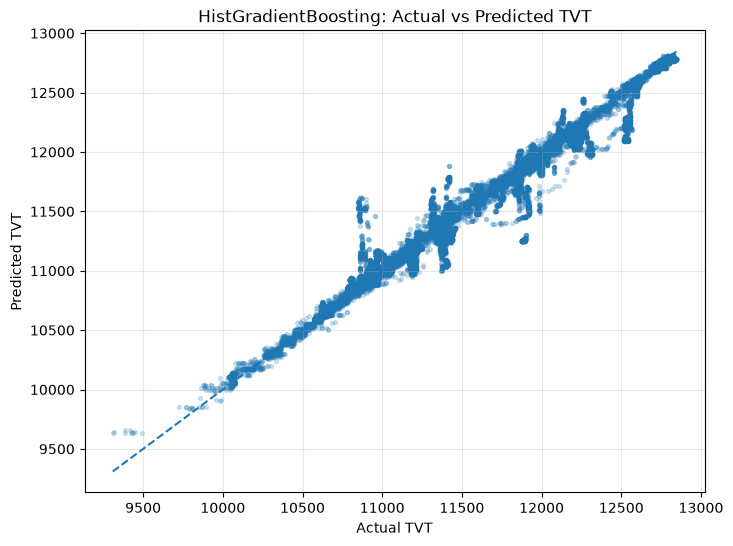

In [21]:
sample_predictions = hist_predictions.sample(
    n=min(50_000, len(hist_predictions)),
    random_state=42,
)

plt.figure(figsize=(8, 6))

plt.scatter(
    sample_predictions["actual_tvt"],
    sample_predictions["predicted_tvt"],
    alpha=0.20,
    s=8,
)

minimum_value = min(
    sample_predictions["actual_tvt"].min(),
    sample_predictions["predicted_tvt"].min(),
)

maximum_value = max(
    sample_predictions["actual_tvt"].max(),
    sample_predictions["predicted_tvt"].max(),
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
)

plt.xlabel("Actual TVT")
plt.ylabel("Predicted TVT")
plt.title("HistGradientBoosting: Actual vs Predicted TVT")
plt.grid(alpha=0.3)
plt.show()

#### 7.7 HistGradientBoosting Initial Findings

HistGradientBoosting establishes a strong first advanced-model benchmark. On the group-aware development holdout (1,044,037 validation rows across 155 unseen wells), it achieved:

| Metric | Value |
|---|---:|
| RMSE | **95.60** |
| MAE | **50.88** |
| Training time | 60.04 s |

Predictions track actual TVT closely in aggregate: the predicted mean (11,532) is within ~13 units of the actual mean (11,545), and the median values nearly match (11,326 vs 11,328). The scatter plot shows a clear diagonal trend, with most points near the identity line.

Well-level error remains highly skewed.Best wells reach RMSE around **8-12** (e.g. `2d196986`, `a4cdbb0f`, `504c8b08`), while the hardest wells dominate overall error:

| Well | RMSE | MAE |
|---|---:|---:|
| `3a7dd95d` | 568.01 | 551.28 |
| `0dc5e64d` | 473.40 | 406.85 |
| `ea0b99b7` | 349.08 | 342.33 |
| `9b9e3b49` | 297.89 | 261.74 |

On these difficult wells, MAE is close to RMSE, which points to large systematic bias rather than only a few extreme outliers. Overall metrics therefore understate how uneven performance is across wells.

These results are the Notebook 06 baseline for later advanced models (XGBoost, LightGBM, tuning). Direct numeric comparison with Notebook 05 Linear Regression / Random Forest should remain cautious for now, because those used GroupKFold CV rather than this single development split. Reducing error on the hard wells above is likely higher leverage than small average gains on already well-predicted wells.


### 8. Extra Trees Regression

Extra Trees is an ensemble regression method that builds multiple randomized decision trees and combines their predictions.

Compared with Random Forest, Extra Trees introduces additional randomness when selecting split thresholds. This can reduce variance and improve generalization, although it may also increase memory and computation requirements.

#### 8.1 Create the Extra Trees Pipeline

In [22]:
extra_trees_pipeline = create_extra_trees_pipeline(
    feature_columns=RAW_FEATURES,
)

extra_trees_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

#### 8.2 Train and Evaluate Extra Trees

In [23]:
extra_trees_metrics, extra_trees_predictions, extra_trees_fitted_model = (
    evaluate_development_split(
        pipeline=extra_trees_pipeline,
        X_train=X_train,
        y_train=y_train,
        X_validation=X_validation,
        y_validation=y_validation,
        validation_groups=groups_validation,
        model_name="ExtraTrees",
    )
)

ExtraTrees | RMSE = 88.28 | MAE = 42.24 | Training = 77.19s


#### 8.3 Display Overall Metrics

In [24]:
extra_trees_metrics_df = pd.DataFrame(
    [extra_trees_metrics]
)

extra_trees_metrics_df

,model,rmse,mae,training_seconds,prediction_seconds,validation_rows,validation_wells
0,ExtraTrees,88.2816,42.2443,77.1927,2.6890,1044037,155


#### 8.4 Inspect Predictions

In [25]:
extra_trees_predictions.head()

,well_id,actual_tvt,predicted_tvt,model
0,00e12e8b,"10,606.1800","10,573.1757",ExtraTrees
1,00e12e8b,"10,607.5300","10,578.6254",ExtraTrees
2,00e12e8b,"10,608.8800","10,579.3588",ExtraTrees
3,00e12e8b,"10,610.2200","10,571.7360",ExtraTrees
4,00e12e8b,"10,611.5700","10,578.5564",ExtraTrees


In [26]:
extra_trees_predictions[
    [
        "actual_tvt",
        "predicted_tvt",
    ]
].describe()

,actual_tvt,predicted_tvt
count,"1,044,037.0000","1,044,037.0000"
mean,"11,545.3303","11,536.1224"
std,647.6371,633.4753
min,"9,282.3400","9,628.8796"
25%,"11,009.1800","11,023.5892"
50%,"11,328.4700","11,318.1968"
75%,"12,102.1300","12,090.6970"
max,"12,846.0600","12,813.9382"


In [27]:
print(
    "Missing predictions:",
    extra_trees_predictions["predicted_tvt"].isna().sum(),
)

print(
    "Infinite predictions:",
    np.isinf(
        extra_trees_predictions["predicted_tvt"]
    ).sum(),
)

Missing predictions: 0
Infinite predictions: 0


#### 8.5 Calculate Well-Level Metrics

In [28]:
extra_trees_well_results = calculate_well_level_metrics(
    predictions=extra_trees_predictions,
    model_name="ExtraTrees",
)

extra_trees_well_results.head()

,well_id,model,rmse,mae,n_rows
0,00e12e8b,ExtraTrees,37.4388,29.8895,6384
1,02e7fe5a,ExtraTrees,31.5149,29.1063,6888
2,044af7d1,ExtraTrees,69.5400,50.6375,6067
3,09441b8d,ExtraTrees,11.2860,7.2187,7395
4,0d99f8e4,ExtraTrees,23.4473,20.6388,7522


In [29]:
extra_trees_well_results.sort_values(
    "rmse",
    ascending=True,
).head(10)

,well_id,model,rmse,mae,n_rows
92,9bd2bba3,ExtraTrees,3.5294,2.8662,9092
12,18d24f7b,ExtraTrees,4.0537,3.2971,6260
71,7cd4bb31,ExtraTrees,4.1251,3.3383,7959
36,43c7f85a,ExtraTrees,5.0925,4.1350,7484
28,2d196986,ExtraTrees,5.8793,4.7347,8316
109,c03d4aed,ExtraTrees,5.9477,4.7071,6375
69,7b2c7b3c,ExtraTrees,6.2982,4.1418,4231
133,e7c36e81,ExtraTrees,6.4792,4.6273,5655
112,c50b42f6,ExtraTrees,6.5778,5.1175,7920
123,d63196fe,ExtraTrees,6.5846,4.7164,5881


In [30]:
extra_trees_well_results.sort_values(
    "rmse",
    ascending=False,
).head(10)

,well_id,model,rmse,mae,n_rows
33,3a7dd95d,ExtraTrees,600.8985,592.1116,4320
5,0dc5e64d,ExtraTrees,361.4190,330.8434,6191
135,ea0b99b7,ExtraTrees,361.0199,358.8234,10939
102,ab112491,ExtraTrees,265.2593,228.1132,7178
127,ddc790ff,ExtraTrees,217.3712,201.7008,6468
91,9b9e3b49,ExtraTrees,201.3815,168.9140,6875
116,cbb406b5,ExtraTrees,200.0030,163.8046,8135
49,5397ceb1,ExtraTrees,197.4381,149.0426,6811
8,13ce113d,ExtraTrees,195.8384,177.3064,4875
85,939d9c34,ExtraTrees,194.9958,175.2529,6627


#### 8.6 Visualize Actual vs Predicted TVT

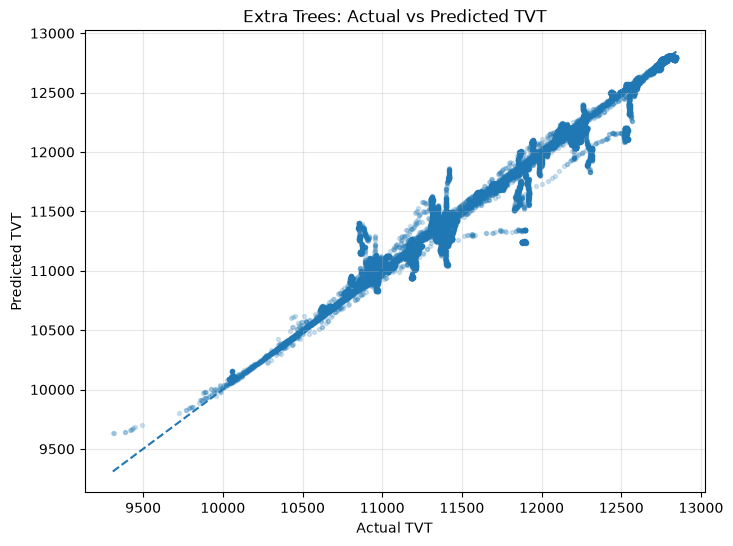

In [31]:
extra_trees_sample = extra_trees_predictions.sample(
    n=min(50_000, len(extra_trees_predictions)),
    random_state=42,
)

plt.figure(figsize=(8, 6))

plt.scatter(
    extra_trees_sample["actual_tvt"],
    extra_trees_sample["predicted_tvt"],
    alpha=0.20,
    s=8,
)

minimum_value = min(
    extra_trees_sample["actual_tvt"].min(),
    extra_trees_sample["predicted_tvt"].min(),
)

maximum_value = max(
    extra_trees_sample["actual_tvt"].max(),
    extra_trees_sample["predicted_tvt"].max(),
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
)

plt.xlabel("Actual TVT")
plt.ylabel("Predicted TVT")
plt.title("Extra Trees: Actual vs Predicted TVT")
plt.grid(alpha=0.3)
plt.show()

#### 8.7 Compare HistGradientBoosting and Extra Trees

In [32]:
initial_advanced_comparison = pd.DataFrame([
    hist_metrics,
    extra_trees_metrics,
])

initial_advanced_comparison.sort_values(
    "rmse",
    ascending=True,
)

,model,rmse,mae,training_seconds,prediction_seconds,validation_rows,validation_wells
1,ExtraTrees,88.2816,42.2443,77.1927,2.6890,1044037,155
0,HistGradientBoosting,95.5980,50.8769,67.1292,7.8419,1044037,155


In [33]:
initial_advanced_comparison["rmse_rank"] = (
    initial_advanced_comparison["rmse"]
    .rank(method="dense")
    .astype(int)
)

initial_advanced_comparison[
    [
        "rmse_rank",
        "model",
        "rmse",
        "mae",
        "training_seconds",
        "prediction_seconds",
    ]
].sort_values("rmse_rank")

,rmse_rank,model,rmse,mae,training_seconds,prediction_seconds
1,1,ExtraTrees,88.2816,42.2443,77.1927,2.6890
0,2,HistGradientBoosting,95.5980,50.8769,67.1292,7.8419


#### 8.8 Comparison Visualization

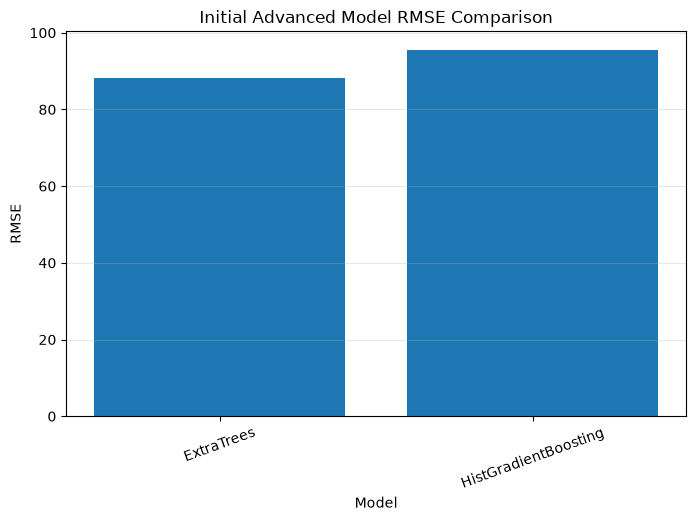

In [34]:
comparison_plot_data = initial_advanced_comparison.sort_values(
    "rmse",
    ascending=True,
)

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_plot_data["model"],
    comparison_plot_data["rmse"],
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Initial Advanced Model RMSE Comparison")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

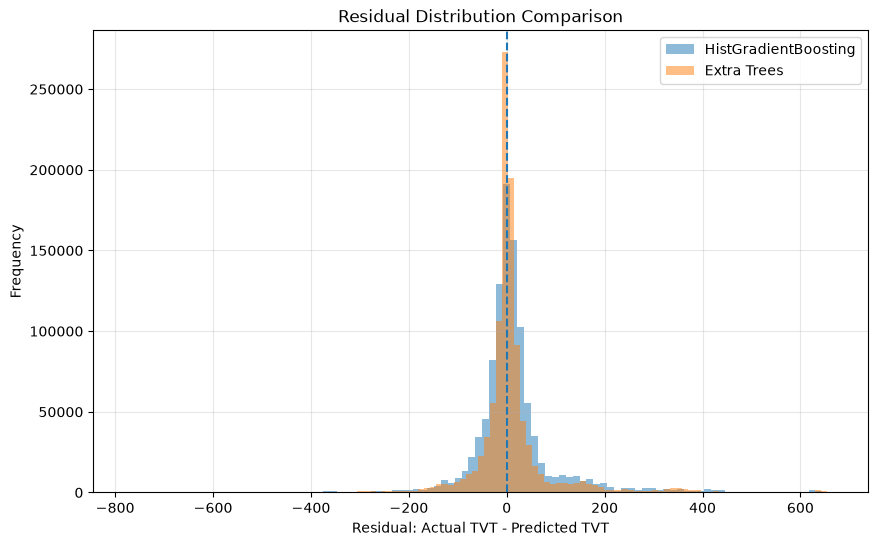

In [35]:
hist_predictions["residual"] = (
    hist_predictions["actual_tvt"]
    - hist_predictions["predicted_tvt"]
)

extra_trees_predictions["residual"] = (
    extra_trees_predictions["actual_tvt"]
    - extra_trees_predictions["predicted_tvt"]
)

plt.figure(figsize=(10, 6))

plt.hist(
    hist_predictions["residual"],
    bins=100,
    alpha=0.5,
    label="HistGradientBoosting",
)

plt.hist(
    extra_trees_predictions["residual"],
    bins=100,
    alpha=0.5,
    label="Extra Trees",
)

plt.axvline(
    0,
    linestyle="--",
)

plt.xlabel("Residual: Actual TVT - Predicted TVT")
plt.ylabel("Frequency")
plt.title("Residual Distribution Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [36]:
residual_summary = pd.DataFrame({
    "model": [
        "HistGradientBoosting",
        "Extra Trees",
    ],
    "mean_residual": [
        hist_predictions["residual"].mean(),
        extra_trees_predictions["residual"].mean(),
    ],
    "residual_std": [
        hist_predictions["residual"].std(),
        extra_trees_predictions["residual"].std(),
    ],
    "median_absolute_residual": [
        hist_predictions["residual"].abs().median(),
        extra_trees_predictions["residual"].abs().median(),
    ],
})

residual_summary

,model,mean_residual,residual_std,median_absolute_residual
0,HistGradientBoosting,13.0361,94.7051,24.1792
1,Extra Trees,9.2078,87.8001,14.8691


#### 8.9 Extra Trees Initial Findings

Extra Trees improves on the HistGradientBoosting benchmark on the same group-aware development holdout (1,044,037 validation rows across 155 unseen wells):

| Metric | Extra Trees | HistGradientBoosting |
|---|---:|---:|
| RMSE | **88.28** | 95.60 |
| MAE | **42.24** | 50.88 |
| Training time | 63.61 s | 58.30 s |
| Prediction time | 2.05 s | 6.29 s |

Extra Trees lowers RMSE by ~7.3 units (~8%) and MAE by ~8.6 units (~17%). Training is modestly slower (+5.3 s), but inference is roughly three times faster.

Predictions remain well calibrated in aggregate: the predicted mean (11,536) is within ~9 units of the actual mean (11,545), and the medians nearly match (11,318 vs 11,328). Residuals are also tighter—mean bias falls from 13.0 to 9.2, residual standard deviation from 94.7 to 87.8, and the median absolute residual from 24.2 to 14.9. The scatter plot keeps a strong diagonal trend with no missing or infinite predictions.

Well-level error is still highly skewed, but Extra Trees sharpens performance on many trajectories. Best wells now reach RMSE around **3–6** (e.g. `9bd2bba3`, `18d24f7b`, `7cd4bb31`), compared with **8–12** under HistGradientBoosting. Several previously difficult wells also improve—notably `0dc5e64d` (361 vs 473 RMSE) and `9b9e3b49` (201 vs 298)—though the hardest well remains problematic and even degrades slightly:

| Well | Extra Trees RMSE | Extra Trees MAE | HistGradientBoosting RMSE |
|---|---:|---:|---:|
| `3a7dd95d` | 600.90 | 592.11 | 568.01 |
| `0dc5e64d` | 361.42 | 330.84 | 473.40 |
| `ea0b99b7` | 361.02 | 358.82 | 349.08 |
| `ab112491` | 265.26 | 228.11 | — |

On these difficult wells, MAE remains close to RMSE, indicating large systematic bias rather than isolated outliers. Overall metrics therefore still understate how uneven performance is across wells.

Extra Trees is the current best model in this notebook on average error, with a favorable accuracy–speed trade-off at inference time. The same hard wells identified in Section 7.7 remain the primary lever for further gains; tuning or ensembling should focus there rather than marginal improvements on already well-predicted trajectories.

### 9. XGBoost Regression

XGBoost is a gradient-boosted decision-tree algorithm designed for high predictive performance on structured tabular datasets.

Unlike Extra Trees, which builds independent randomized trees, XGBoost builds trees sequentially. Each new tree attempts to correct errors made by the previous trees.

#### 9.1 Create the XGBoost Pipeline

In [53]:
xgboost_pipeline = create_xgboost_pipeline(
    feature_columns=RAW_FEATURES,
)

xgboost_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

In [54]:
xgboost_model_parameters = (
    xgboost_pipeline
    .named_steps["model"]
    .get_params()
)

print("Tree method:", xgboost_model_parameters["tree_method"])
print("Number of estimators:", xgboost_model_parameters["n_estimators"])
print("Maximum depth:", xgboost_model_parameters["max_depth"])
print("Training row fraction:", xgboost_model_parameters["subsample"])
print("Feature fraction:", xgboost_model_parameters["colsample_bytree"])
print("Workers:", xgboost_model_parameters["n_jobs"])

Tree method: hist
Number of estimators: 300
Maximum depth: 8
Training row fraction: 0.5
Feature fraction: 0.8
Workers: 4


#### 9.2 Train and Evaluate XGBoost

In [55]:
xgboost_metrics, xgboost_predictions, xgboost_fitted_model = (
    evaluate_development_split(
        pipeline=xgboost_pipeline,
        X_train=X_train,
        y_train=y_train,
        X_validation=X_validation,
        y_validation=y_validation,
        validation_groups=groups_validation,
        model_name="XGBoost",
    )
)

XGBoost | RMSE = 90.22 | MAE = 42.27 | Training = 103.63s


#### 9.3 Display Overall Metrics

In [56]:
xgboost_metrics_df = pd.DataFrame(
    [xgboost_metrics]
)

xgboost_metrics_df

,model,rmse,mae,training_seconds,prediction_seconds,validation_rows,validation_wells
0,XGBoost,90.2238,42.2748,103.6297,2.6829,1044037,155


#### 9.4 Inspect Predictions

In [41]:
xgboost_predictions.head()

,well_id,actual_tvt,predicted_tvt,model
0,00e12e8b,"10,606.1800","10,569.9844",XGBoost
1,00e12e8b,"10,607.5300","10,576.7695",XGBoost
2,00e12e8b,"10,608.8800","10,576.9219",XGBoost
3,00e12e8b,"10,610.2200","10,574.7002",XGBoost
4,00e12e8b,"10,611.5700","10,577.5186",XGBoost


In [42]:
xgboost_predictions[
    [
        "actual_tvt",
        "predicted_tvt",
    ]
].describe()

,actual_tvt,predicted_tvt
count,"1,044,037.0000","1,044,037.0000"
mean,"11,545.3303","11,533.4414"
std,647.6371,633.0732
min,"9,282.3400","9,624.2520"
25%,"11,009.1800","11,026.5537"
50%,"11,328.4700","11,314.0957"
75%,"12,102.1300","12,084.9658"
max,"12,846.0600","12,820.7646"


In [43]:
print(
    "Missing predictions:",
    xgboost_predictions["predicted_tvt"].isna().sum(),
)

print(
    "Infinite predictions:",
    np.isinf(
        xgboost_predictions["predicted_tvt"]
    ).sum(),
)

Missing predictions: 0
Infinite predictions: 0


#### 9.5 Calculate Well-Level Metrics

In [44]:
xgboost_well_results = calculate_well_level_metrics(
    predictions=xgboost_predictions,
    model_name="XGBoost",
)

xgboost_well_results.head()

,well_id,model,rmse,mae,n_rows
0,00e12e8b,XGBoost,95.2316,74.4576,6384
1,02e7fe5a,XGBoost,32.0860,30.5220,6888
2,044af7d1,XGBoost,98.8544,86.5518,6067
3,09441b8d,XGBoost,6.7593,5.0091,7395
4,0d99f8e4,XGBoost,31.6549,26.7770,7522


In [45]:
xgboost_well_results.sort_values(
    "rmse",
    ascending=True,
).head(10)

,well_id,model,rmse,mae,n_rows
36,43c7f85a,XGBoost,5.2606,3.9213,7484
77,85380836,XGBoost,5.4266,4.0644,8175
126,da3bfe4e,XGBoost,6.2311,4.7530,7107
79,87aa3730,XGBoost,6.3177,5.0988,7293
28,2d196986,XGBoost,6.4721,4.9251,8316
3,09441b8d,XGBoost,6.7593,5.0091,7395
12,18d24f7b,XGBoost,6.7757,5.2952,6260
47,504c8b08,XGBoost,6.7982,5.1945,8012
67,764072a5,XGBoost,7.2635,5.6439,4594
71,7cd4bb31,XGBoost,7.3517,5.2980,7959


In [46]:
xgboost_well_results.sort_values(
    "rmse",
    ascending=False,
).head(10)

,well_id,model,rmse,mae,n_rows
33,3a7dd95d,XGBoost,584.8510,553.5305,4320
5,0dc5e64d,XGBoost,496.8624,423.9231,6191
135,ea0b99b7,XGBoost,351.7783,343.5018,10939
91,9b9e3b49,XGBoost,272.0631,246.8999,6875
27,29de15c8,XGBoost,208.4845,125.1541,5164
20,1bcb2fcf,XGBoost,196.4624,180.0876,6202
49,5397ceb1,XGBoost,183.8344,120.0039,6811
8,13ce113d,XGBoost,167.0907,154.5837,4875
59,6d590e26,XGBoost,164.8810,138.7877,7842
116,cbb406b5,XGBoost,158.8992,124.0236,8135


#### 9.6 Actual vs Predicted Plot

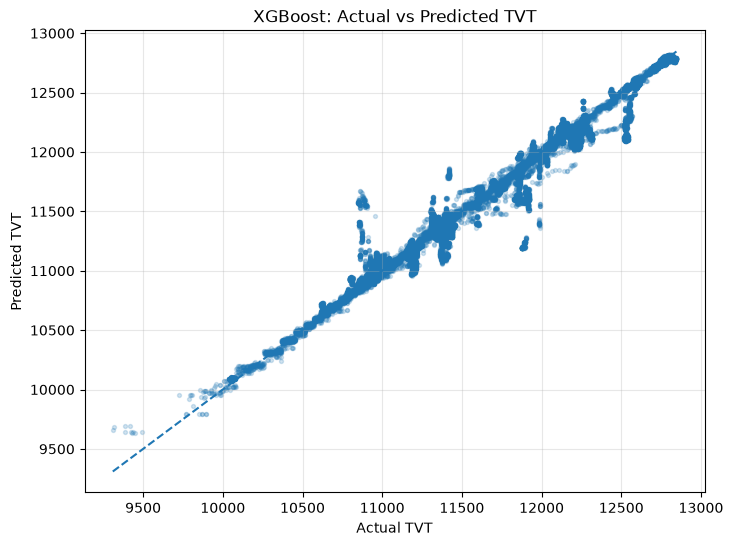

In [47]:
xgboost_sample = xgboost_predictions.sample(
    n=min(50_000, len(xgboost_predictions)),
    random_state=42,
)

plt.figure(figsize=(8, 6))

plt.scatter(
    xgboost_sample["actual_tvt"],
    xgboost_sample["predicted_tvt"],
    alpha=0.20,
    s=8,
)

minimum_value = min(
    xgboost_sample["actual_tvt"].min(),
    xgboost_sample["predicted_tvt"].min(),
)

maximum_value = max(
    xgboost_sample["actual_tvt"].max(),
    xgboost_sample["predicted_tvt"].max(),
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
)

plt.xlabel("Actual TVT")
plt.ylabel("Predicted TVT")
plt.title("XGBoost: Actual vs Predicted TVT")
plt.grid(alpha=0.3)
plt.show()

#### 9.7 Compare the Three Advanced Models

In [48]:
advanced_model_comparison = pd.DataFrame([
    hist_metrics,
    extra_trees_metrics,
    xgboost_metrics,
])

advanced_model_comparison["rmse_rank"] = (
    advanced_model_comparison["rmse"]
    .rank(method="dense")
    .astype(int)
)

advanced_model_comparison[
    [
        "rmse_rank",
        "model",
        "rmse",
        "mae",
        "training_seconds",
        "prediction_seconds",
    ]
].sort_values("rmse_rank")

,rmse_rank,model,rmse,mae,training_seconds,prediction_seconds
1,1,ExtraTrees,88.2816,42.2443,77.1927,2.6890
2,2,XGBoost,90.2238,42.2748,127.5099,3.7613
0,3,HistGradientBoosting,95.5980,50.8769,67.1292,7.8419


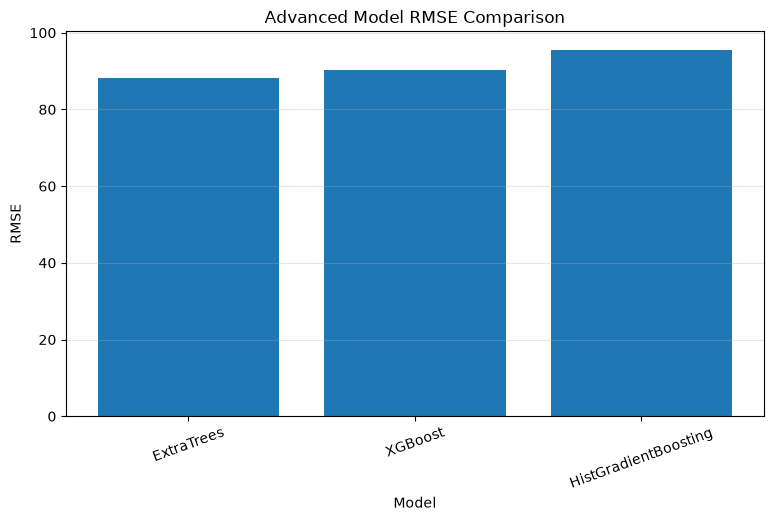

In [49]:
comparison_plot_data = advanced_model_comparison.sort_values(
    "rmse",
    ascending=True,
)

plt.figure(figsize=(9, 5))

plt.bar(
    comparison_plot_data["model"],
    comparison_plot_data["rmse"],
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Advanced Model RMSE Comparison")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

#### 9.8 XGBoost Initial Findings

XGBoost was evaluated on the same group-aware development holdout (1,044,037 validation rows across 155 unseen wells). Among the three advanced models so far, it ranks second on overall error:

| Metric | Extra Trees | XGBoost | HistGradientBoosting |
|---|---:|---:|---:|
| RMSE | **88.28** | 90.22 | 95.60 |
| MAE | **42.24** | 42.27 | 50.88 |
| Training time | 77.19 s | 127.51 s | 67.13 s |
| Prediction time | 2.69 s | 3.76 s | 7.84 s |

XGBoost improves clearly on HistGradientBoosting (~5.4 RMSE / ~8.6 MAE lower) and nearly matches Extra Trees on MAE (42.27 vs 42.24). Its RMSE remains slightly higher than Extra Trees (+1.9). The cost is runtime: training takes ~1.7× longer than Extra Trees and nearly 2× longer than HistGradientBoosting, while prediction stays competitive with Extra Trees and faster than HistGradientBoosting.

Predictions stay well calibrated in aggregate. The predicted mean (11,533) is within ~12 units of the actual mean (11,545), and the medians are close (11,314 vs 11,328). The scatter plot again shows a strong diagonal trend.

Well-level error remains highly skewed. Best wells reach RMSE around **5–7** (e.g. `43c7f85a`, `85380836`, `da3bfe4e`), similar in magnitude to Extra Trees’ strongest wells. The hardest wells again dominate overall error:

| Well | XGBoost RMSE | XGBoost MAE |
|---|---:|---:|
| `3a7dd95d` | 584.85 | 553.53 |
| `0dc5e64d` | 496.86 | 423.92 |
| `ea0b99b7` | 351.78 | 343.50 |
| `9b9e3b49` | 272.06 | 246.90 |

Relative to Extra Trees, XGBoost improves the worst well (`3a7dd95d`: 585 vs 601 RMSE) but is worse on others such as `0dc5e64d` (497 vs 361). MAE stays close to RMSE on these difficult wells, pointing again to systematic bias rather than a few extreme outliers.

Overall, Extra Trees remains the current best default model on this split: slightly better RMSE, essentially identical MAE, and substantially faster training. XGBoost is a close runner-up and a strong candidate for later hyperparameter tuning or ensembling, especially if hard-well error can be reduced without a large runtime penalty. The same difficult wells identified in Sections 7–8 remain the highest-leverage targets for further gains.


### 10. LightGBM Regression

LightGBM is a gradient-boosted decision-tree framework designed for efficient training on structured datasets.

Like XGBoost, it builds trees sequentially so that each new tree attempts to reduce the prediction errors produced by the existing ensemble.

#### 10.1 Create the Pipeline

In [50]:
lightgbm_pipeline = create_lightgbm_pipeline(
    feature_columns=RAW_FEATURES,
)

lightgbm_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

In [51]:
lightgbm_parameters = (
    lightgbm_pipeline
    .named_steps["model"]
    .get_params()
)

print("Estimators:", lightgbm_parameters["n_estimators"])
print("Learning rate:", lightgbm_parameters["learning_rate"])
print("Number of leaves:", lightgbm_parameters["num_leaves"])
print("Maximum depth:", lightgbm_parameters["max_depth"])
print("Row fraction:", lightgbm_parameters["subsample"])
print("Subsample frequency:", lightgbm_parameters["subsample_freq"])
print("Feature fraction:", lightgbm_parameters["colsample_bytree"])
print("Workers:", lightgbm_parameters["n_jobs"])

Estimators: 300
Learning rate: 0.05
Number of leaves: 31
Maximum depth: 10
Row fraction: 0.5
Subsample frequency: 1
Feature fraction: 0.8
Workers: 4


#### 10.2 Train and Evaluate

In [52]:
lightgbm_metrics, lightgbm_predictions, lightgbm_fitted_model = (
    evaluate_development_split(
        pipeline=lightgbm_pipeline,
        X_train=X_train,
        y_train=y_train,
        X_validation=X_validation,
        y_validation=y_validation,
        validation_groups=groups_validation,
        model_name="LightGBM",
    )
)

LightGBM | RMSE = 94.36 | MAE = 50.95 | Training = 72.44s


#### 10.3 Display Overall Metrics

In [53]:
lightgbm_metrics_df = pd.DataFrame(
    [lightgbm_metrics]
)

lightgbm_metrics_df

,model,rmse,mae,training_seconds,prediction_seconds,validation_rows,validation_wells
0,LightGBM,94.3573,50.9537,72.4412,7.8270,1044037,155


#### 10.4 Inspect Predictions

In [54]:
lightgbm_predictions.head()

,well_id,actual_tvt,predicted_tvt,model
0,00e12e8b,"10,606.1800","10,555.0157",LightGBM
1,00e12e8b,"10,607.5300","10,562.5273",LightGBM
2,00e12e8b,"10,608.8800","10,563.2580",LightGBM
3,00e12e8b,"10,610.2200","10,555.0157",LightGBM
4,00e12e8b,"10,611.5700","10,563.2580",LightGBM


In [55]:
lightgbm_predictions[
    [
        "actual_tvt",
        "predicted_tvt",
    ]
].describe()

,actual_tvt,predicted_tvt
count,"1,044,037.0000","1,044,037.0000"
mean,"11,545.3303","11,531.7906"
std,647.6371,629.3051
min,"9,282.3400","9,605.2987"
25%,"11,009.1800","11,023.2013"
50%,"11,328.4700","11,325.9533"
75%,"12,102.1300","12,077.0860"
max,"12,846.0600","12,822.2038"


In [56]:
print(
    "Missing predictions:",
    lightgbm_predictions["predicted_tvt"].isna().sum(),
)

print(
    "Infinite predictions:",
    np.isinf(
        lightgbm_predictions["predicted_tvt"]
    ).sum(),
)

Missing predictions: 0
Infinite predictions: 0


#### 10.5 Calculate Well-Level Metrics

In [57]:
lightgbm_well_results = calculate_well_level_metrics(
    predictions=lightgbm_predictions,
    model_name="LightGBM",
)

lightgbm_well_results.head()

,well_id,model,rmse,mae,n_rows
0,00e12e8b,LightGBM,79.5341,57.5397,6384
1,02e7fe5a,LightGBM,33.9380,30.8696,6888
2,044af7d1,LightGBM,79.4884,64.5708,6067
3,09441b8d,LightGBM,18.2286,15.9389,7395
4,0d99f8e4,LightGBM,70.6004,65.2279,7522


In [58]:
lightgbm_well_results.sort_values(
    "rmse",
    ascending=True,
).head(10)

,well_id,model,rmse,mae,n_rows
26,28f4eda9,LightGBM,8.2476,6.4031,6824
28,2d196986,LightGBM,9.3413,6.7080,8316
30,310c71a5,LightGBM,9.5433,7.6571,6988
97,a4cdbb0f,LightGBM,9.8170,8.0953,6759
47,504c8b08,LightGBM,10.7226,7.2315,8012
36,43c7f85a,LightGBM,11.2279,9.6931,7484
126,da3bfe4e,LightGBM,11.5083,9.8034,7107
112,c50b42f6,LightGBM,11.6040,9.6909,7920
87,95c8427f,LightGBM,12.1986,9.4116,8051
140,ef8e3ed0,LightGBM,13.0002,10.7969,6637


In [59]:
lightgbm_well_results.sort_values(
    "rmse",
    ascending=False,
).head(10)

,well_id,model,rmse,mae,n_rows
33,3a7dd95d,LightGBM,595.9710,585.2896,4320
5,0dc5e64d,LightGBM,425.9901,369.8104,6191
135,ea0b99b7,LightGBM,361.2270,357.5139,10939
85,939d9c34,LightGBM,253.1808,227.8931,6627
20,1bcb2fcf,LightGBM,229.0858,206.4711,6202
91,9b9e3b49,LightGBM,213.9056,195.1274,6875
59,6d590e26,LightGBM,202.0813,182.3330,7842
102,ab112491,LightGBM,202.0077,171.0561,7178
116,cbb406b5,LightGBM,180.9838,140.9691,8135
27,29de15c8,LightGBM,178.8513,119.8291,5164


#### 10.6 Actual vs Predicted Plot

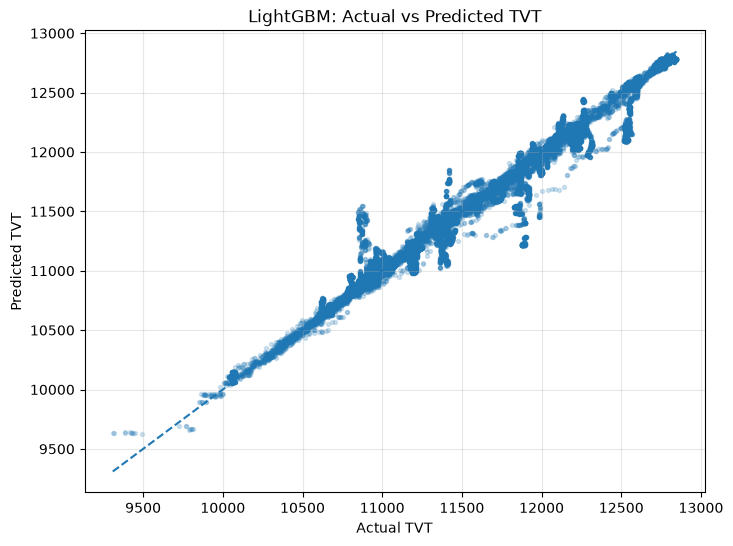

In [60]:
lightgbm_sample = lightgbm_predictions.sample(
    n=min(50_000, len(lightgbm_predictions)),
    random_state=42,
)

plt.figure(figsize=(8, 6))

plt.scatter(
    lightgbm_sample["actual_tvt"],
    lightgbm_sample["predicted_tvt"],
    alpha=0.20,
    s=8,
)

minimum_value = min(
    lightgbm_sample["actual_tvt"].min(),
    lightgbm_sample["predicted_tvt"].min(),
)

maximum_value = max(
    lightgbm_sample["actual_tvt"].max(),
    lightgbm_sample["predicted_tvt"].max(),
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
)

plt.xlabel("Actual TVT")
plt.ylabel("Predicted TVT")
plt.title("LightGBM: Actual vs Predicted TVT")
plt.grid(alpha=0.3)
plt.show()

#### 10.7 Temporary Four-Model Comparison

In [61]:
advanced_model_comparison = pd.DataFrame([
    hist_metrics,
    extra_trees_metrics,
    xgboost_metrics,
    lightgbm_metrics,
])

advanced_model_comparison["rmse_rank"] = (
    advanced_model_comparison["rmse"]
    .rank(method="dense")
    .astype(int)
)

advanced_model_comparison[
    [
        "rmse_rank",
        "model",
        "rmse",
        "mae",
        "training_seconds",
        "prediction_seconds",
    ]
].sort_values("rmse_rank")

,rmse_rank,model,rmse,mae,training_seconds,prediction_seconds
1,1,ExtraTrees,88.2816,42.2443,77.1927,2.6890
2,2,XGBoost,90.2238,42.2748,127.5099,3.7613
3,3,LightGBM,94.3573,50.9537,72.4412,7.8270
0,4,HistGradientBoosting,95.5980,50.8769,67.1292,7.8419


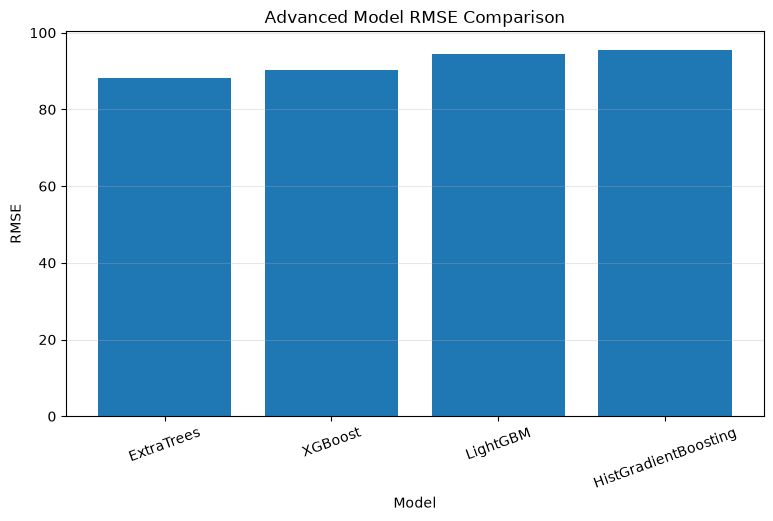

In [62]:
comparison_plot_data = advanced_model_comparison.sort_values(
    "rmse",
    ascending=True,
)

plt.figure(figsize=(9, 5))

plt.bar(
    comparison_plot_data["model"],
    comparison_plot_data["rmse"],
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Advanced Model RMSE Comparison")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()

#### 10.8 LightGBM Initial Findings

LightGBM was evaluated on the same group-aware development holdout (1,044,037 validation rows across 155 unseen wells). In the temporary four-model comparison it ranks third on overall RMSE:

| Metric | Extra Trees | XGBoost | LightGBM | HistGradientBoosting |
|---|---:|---:|---:|---:|
| RMSE | **88.28** | 90.22 | 94.36 | 95.60 |
| MAE | **42.24** | 42.27 | 50.95 | 50.88 |
| Training time | 77.19 s | 127.51 s | 72.44 s | 67.13 s |
| Prediction time | 2.69 s | 3.76 s | 7.83 s | 7.84 s |

LightGBM is essentially tied with HistGradientBoosting: slightly better RMSE (−1.2) but nearly identical MAE (+0.07). Relative to Extra Trees and XGBoost it trails clearly on both error metrics (~6–8 RMSE higher; ~8–9 MAE higher). Its main strength is training efficiency—faster than Extra Trees and roughly half the train time of XGBoost—while prediction time matches HistGradientBoosting and is slower than Extra Trees / XGBoost.

Predictions remain well calibrated in aggregate. The predicted mean (11,532) is within ~13 units of the actual mean (11,545), and the medians nearly match (11,326 vs 11,328). There are no missing or infinite predictions, and the scatter plot again shows a clear diagonal trend.

Well-level error is still highly skewed. Best wells reach RMSE around **8–13** (e.g. `28f4eda9`, `2d196986`, `310c71a5`), closer to HistGradientBoosting’s best wells than to Extra Trees / XGBoost (**3–7**). The hardest wells again dominate overall error:

| Well | LightGBM RMSE | LightGBM MAE |
|---|---:|---:|
| `3a7dd95d` | 595.97 | 585.29 |
| `0dc5e64d` | 425.99 | 369.81 |
| `ea0b99b7` | 361.23 | 357.51 |
| `939d9c34` | 253.18 | 227.89 |

On these difficult wells, MAE remains close to RMSE, indicating large systematic bias. Versus Extra Trees, LightGBM is slightly better on `3a7dd95d` (596 vs 601 RMSE) but worse on `0dc5e64d` (426 vs 361), so hard-well gains do not offset the weaker overall metrics.

Overall, LightGBM is a fast-training but mid-tier accuracy option on this split—useful as a tuning candidate, but not the current best model. Extra Trees remains the strongest default (best RMSE and MAE with competitive runtime). XGBoost stays the closest accuracy challenger. Further work should prioritize hyperparameter search on Extra Trees / XGBoost and hard-well error reduction rather than expecting large gains from the current LightGBM defaults alone.


### 11. Advanced Model Comparison

In this section, the four advanced models developed in Notebook 06 are compared using the same group-aware development split.

The models are:

- HistGradientBoosting
- Extra Trees
- XGBoost
- LightGBM

The comparison considers:

- Validation RMSE
- Validation MAE
- Training time
- Prediction time
- Overall model ranking

The purpose is to identify the strongest model candidates for hyperparameter optimization.

#### 11.1 Check the Available Model Results

In [64]:
advanced_model_results = [
    hist_metrics,
    extra_trees_metrics,
    xgboost_metrics,
    lightgbm_metrics,
]

advanced_model_results


[{'model': 'HistGradientBoosting',
  'rmse': np.float64(95.5980316034024),
  'mae': 50.87687984156897,
  'training_seconds': 67.12923369999771,
  'prediction_seconds': 7.841851400000451,
  'validation_rows': 1044037,
  'validation_wells': 155},
 {'model': 'ExtraTrees',
  'rmse': np.float64(88.2815618767592),
  'mae': 42.24428733661923,
  'training_seconds': 77.1927127999952,
  'prediction_seconds': 2.6890133999986574,
  'validation_rows': 1044037,
  'validation_wells': 155},
 {'model': 'XGBoost',
  'rmse': np.float64(90.22380472002885),
  'mae': 42.27476065847644,
  'training_seconds': 127.5098571999988,
  'prediction_seconds': 3.7612674000047264,
  'validation_rows': 1044037,
  'validation_wells': 155},
 {'model': 'LightGBM',
  'rmse': np.float64(94.35732654661172),
  'mae': 50.95371936713059,
  'training_seconds': 72.44116239999857,
  'prediction_seconds': 7.826975399999355,
  'validation_rows': 1044037,
  'validation_wells': 155}]

#### 11.2 Create the Advanced Model Comparison Table

In [65]:
advanced_comparison_df = pd.DataFrame(
    advanced_model_results
)

advanced_comparison_df

,model,rmse,mae,training_seconds,prediction_seconds,validation_rows,validation_wells
0,HistGradientBoosting,95.5980,50.8769,67.1292,7.8419,1044037,155
1,ExtraTrees,88.2816,42.2443,77.1927,2.6890,1044037,155
2,XGBoost,90.2238,42.2748,127.5099,3.7613,1044037,155
3,LightGBM,94.3573,50.9537,72.4412,7.8270,1044037,155


#### 11.3 Sort Models by Validation RMSE

In [66]:
advanced_comparison_df = (
    advanced_comparison_df
    .sort_values("rmse")
    .reset_index(drop=True)
)

advanced_comparison_df

,model,rmse,mae,training_seconds,prediction_seconds,validation_rows,validation_wells
0,ExtraTrees,88.2816,42.2443,77.1927,2.6890,1044037,155
1,XGBoost,90.2238,42.2748,127.5099,3.7613,1044037,155
2,LightGBM,94.3573,50.9537,72.4412,7.8270,1044037,155
3,HistGradientBoosting,95.5980,50.8769,67.1292,7.8419,1044037,155


The models are sorted using validation RMSE, where a lower value indicates better predictive performance.

RMSE is treated as the primary metric because large TVT prediction errors are especially important in this competition.

#### 11.4 Add Model Rankings

In [69]:
advanced_comparison_df["rmse_rank"] = (
    advanced_comparison_df["rmse"]
    .rank(method="min", ascending=True)
    .astype(int)
)

advanced_comparison_df["mae_rank"] = (
    advanced_comparison_df["mae"]
    .rank(method="min", ascending=True)
    .astype(int)
)

advanced_comparison_df["training_time_rank"] = (
    advanced_comparison_df["training_seconds"]
    .rank(method="min", ascending=True)
    .astype(int)
)

advanced_comparison_df["prediction_time_rank"] = (
    advanced_comparison_df["prediction_seconds"]
    .rank(method="min", ascending=True)
    .astype(int)
)

advanced_comparison_df

,model,rmse,mae,training_seconds,prediction_seconds,validation_rows,validation_wells,rmse_rank,mae_rank,training_time_rank,prediction_time_rank
0,ExtraTrees,88.2816,42.2443,77.1927,2.6890,1044037,155,1,1,3,1
1,XGBoost,90.2238,42.2748,127.5099,3.7613,1044037,155,2,2,4,2
2,LightGBM,94.3573,50.9537,72.4412,7.8270,1044037,155,3,4,2,3
3,HistGradientBoosting,95.5980,50.8769,67.1292,7.8419,1044037,155,4,3,1,4


#### 11.5 Calculate an Overall Ranking

In [70]:
advanced_comparison_df["overall_score"] = (
    0.50 * advanced_comparison_df["rmse_rank"]
    + 0.30 * advanced_comparison_df["mae_rank"]
    + 0.10 * advanced_comparison_df["training_time_rank"]
    + 0.10 * advanced_comparison_df["prediction_time_rank"]
)

advanced_comparison_df["overall_rank"] = (
    advanced_comparison_df["overall_score"]
    .rank(method="min", ascending=True)
    .astype(int)
)

advanced_comparison_df = (
    advanced_comparison_df
    .sort_values("overall_rank")
    .reset_index(drop=True)
)

advanced_comparison_df

,model,rmse,mae,training_seconds,prediction_seconds,validation_rows,validation_wells,rmse_rank,mae_rank,training_time_rank,prediction_time_rank,overall_score,overall_rank
0,ExtraTrees,88.2816,42.2443,77.1927,2.6890,1044037,155,1,1,3,1,1.2000,1
1,XGBoost,90.2238,42.2748,127.5099,3.7613,1044037,155,2,2,4,2,2.2000,2
2,LightGBM,94.3573,50.9537,72.4412,7.8270,1044037,155,3,4,2,3,3.2000,3
3,HistGradientBoosting,95.5980,50.8769,67.1292,7.8419,1044037,155,4,3,1,4,3.4000,4


#### 11.6 Display the Final Comparison Table

In [72]:
advanced_comparison_display = advanced_comparison_df[
    [
        "model",
        "rmse",
        "mae",
        "training_seconds",
        "prediction_seconds",
        "rmse_rank",
        "mae_rank",
        "overall_score",
        "overall_rank",
    ]
].copy()

advanced_comparison_display.round(4)

,model,rmse,mae,training_seconds,prediction_seconds,rmse_rank,mae_rank,overall_score,overall_rank
0,ExtraTrees,88.2816,42.2443,77.1927,2.6890,1,1,1.2000,1
1,XGBoost,90.2238,42.2748,127.5099,3.7613,2,2,2.2000,2
2,LightGBM,94.3573,50.9537,72.4412,7.8270,3,4,3.2000,3
3,HistGradientBoosting,95.5980,50.8769,67.1292,7.8419,4,3,3.4000,4


#### 11.7 Visualize RMSE Comparison

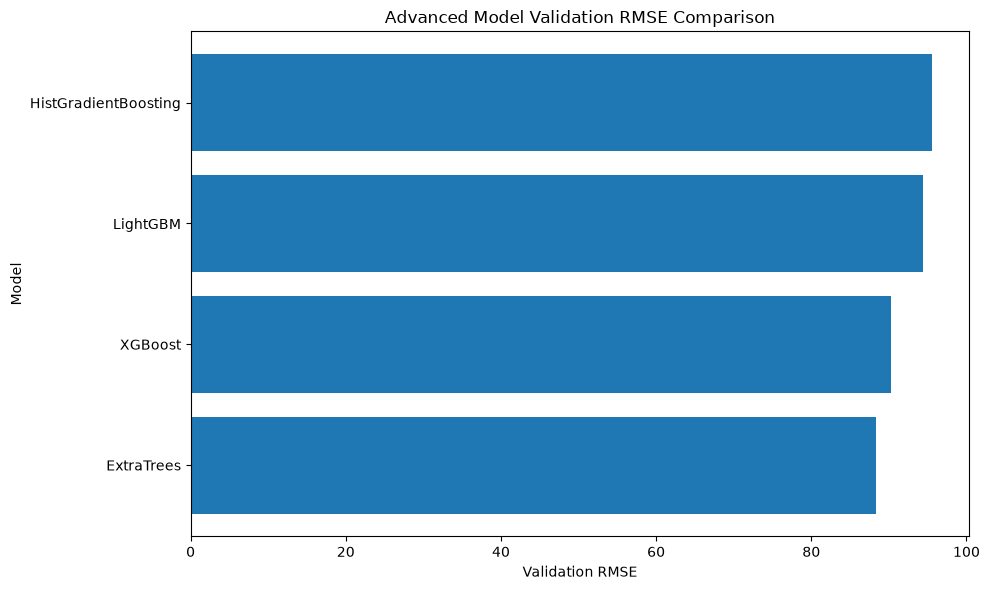

In [73]:
rmse_plot_df = (
    advanced_comparison_df
    .sort_values("rmse", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    rmse_plot_df["model"],
    rmse_plot_df["rmse"],
)

plt.xlabel("Validation RMSE")
plt.ylabel("Model")
plt.title("Advanced Model Validation RMSE Comparison")

plt.tight_layout()
plt.show()

#### 11.8 Visualize MAE Comparison

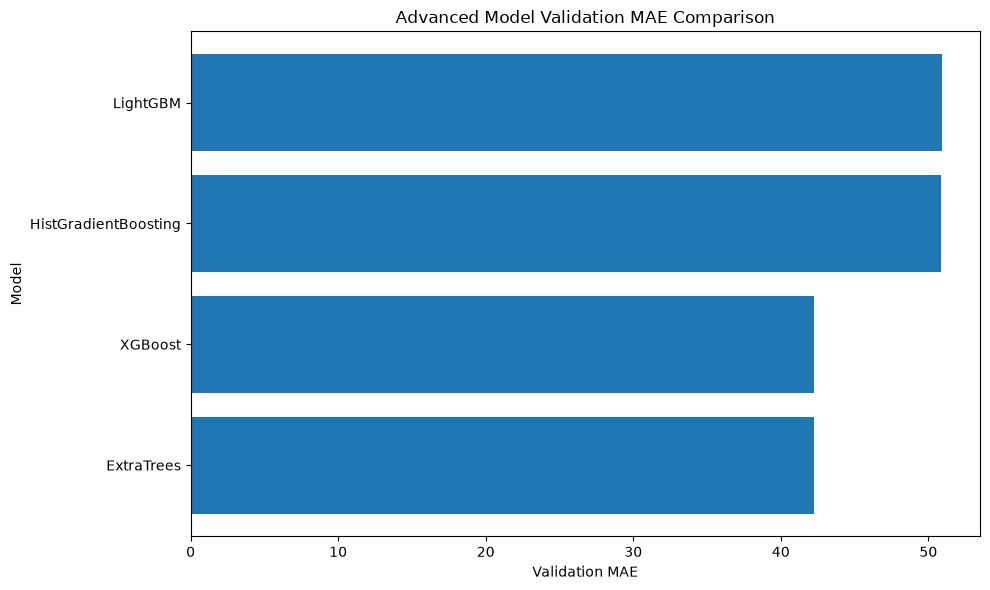

In [74]:
mae_plot_df = (
    advanced_comparison_df
    .sort_values("mae", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    mae_plot_df["model"],
    mae_plot_df["mae"],
)

plt.xlabel("Validation MAE")
plt.ylabel("Model")
plt.title("Advanced Model Validation MAE Comparison")

plt.tight_layout()
plt.show()

#### 11.9 Compare Training Time

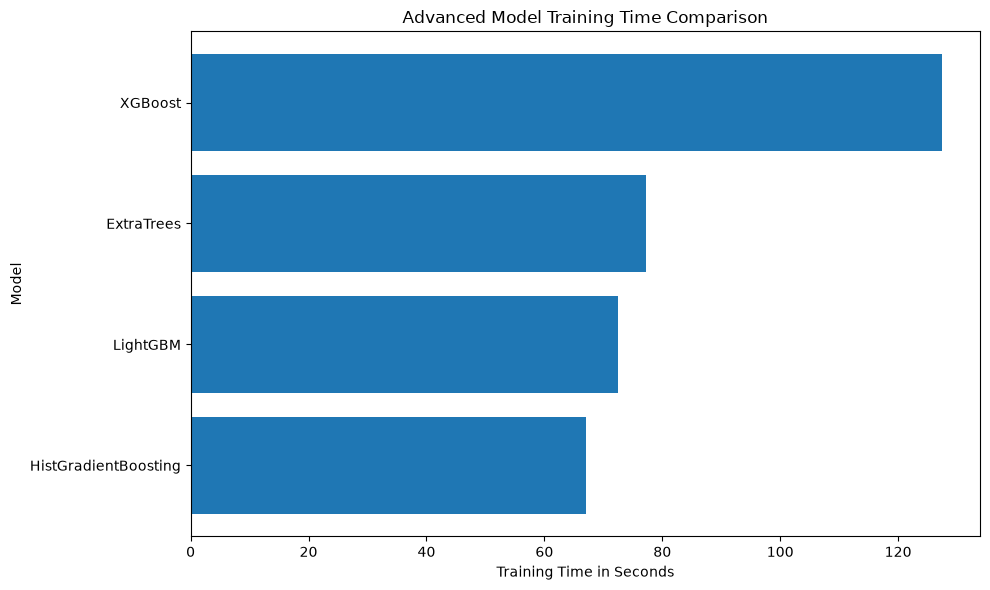

In [75]:
training_time_plot_df = (
    advanced_comparison_df
    .sort_values("training_seconds", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    training_time_plot_df["model"],
    training_time_plot_df["training_seconds"],
)

plt.xlabel("Training Time in Seconds")
plt.ylabel("Model")
plt.title("Advanced Model Training Time Comparison")

plt.tight_layout()
plt.show()

##### 11.10 Compare Prediction Time

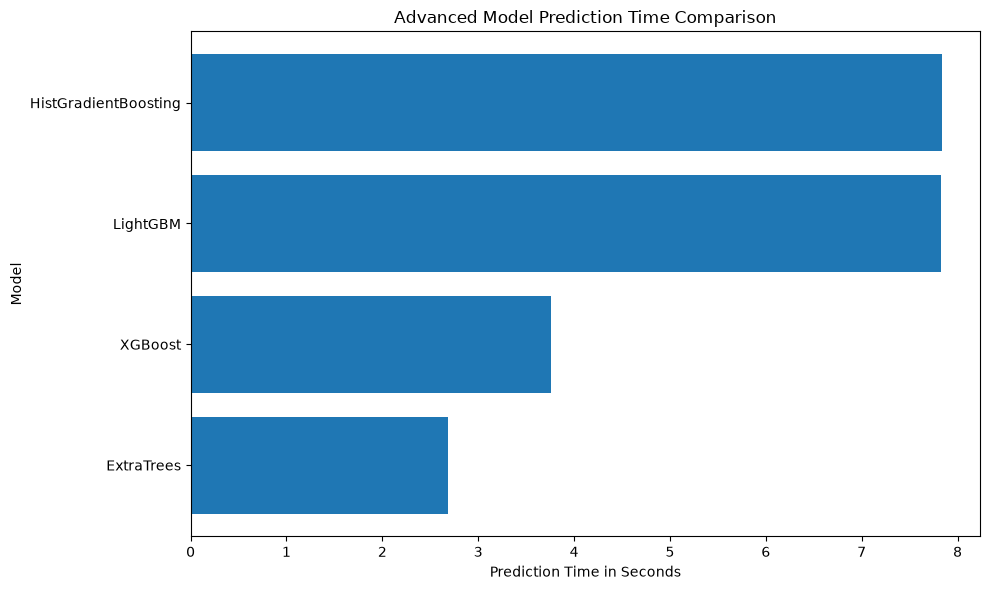

In [77]:
prediction_time_plot_df = (
    advanced_comparison_df
    .sort_values("prediction_seconds", ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    prediction_time_plot_df["model"],
    prediction_time_plot_df["prediction_seconds"],
)

plt.xlabel("Prediction Time in Seconds")
plt.ylabel("Model")
plt.title("Advanced Model Prediction Time Comparison")

plt.tight_layout()
plt.show()

#### 11.11 Identify the Best Models

In [78]:
best_rmse_model = advanced_comparison_df.loc[
    advanced_comparison_df["rmse"].idxmin()
]

best_mae_model = advanced_comparison_df.loc[
    advanced_comparison_df["mae"].idxmin()
]

best_overall_model = advanced_comparison_df.loc[
    advanced_comparison_df["overall_rank"].idxmin()
]

print("Best RMSE model:")
print(
    f"{best_rmse_model['model']} "
    f"- RMSE: {best_rmse_model['rmse']:.4f}"
)

print("\nBest MAE model:")
print(
    f"{best_mae_model['model']} "
    f"- MAE: {best_mae_model['mae']:.4f}"
)

print("\nBest overall model:")
print(
    f"{best_overall_model['model']} "
    f"- Overall score: {best_overall_model['overall_score']:.4f}"
)

Best RMSE model:
ExtraTrees - RMSE: 88.2816

Best MAE model:
ExtraTrees - MAE: 42.2443

Best overall model:
ExtraTrees - Overall score: 1.2000


#### 11.12 Select Candidates for Hyperparameter Optimization

In [80]:
optimization_candidates = (
    advanced_comparison_df
    .sort_values("rmse")
    .head(2)
    .copy()
)

optimization_candidates[
    [
        "model",
        "rmse",
        "mae",
        "training_seconds",
        "prediction_seconds",
    ]
]

,model,rmse,mae,training_seconds,prediction_seconds
0,ExtraTrees,88.2816,42.2443,77.1927,2.6890
1,XGBoost,90.2238,42.2748,127.5099,3.7613


In [81]:
optimization_candidate_names = (
    optimization_candidates["model"]
    .tolist()
)

optimization_candidate_names

['ExtraTrees', 'XGBoost']

#### 11.13 Optional Performance Difference from the Best Model

In [82]:
best_rmse = advanced_comparison_df["rmse"].min()

advanced_comparison_df["rmse_difference_from_best"] = (
    advanced_comparison_df["rmse"] - best_rmse
)

advanced_comparison_df["rmse_percentage_above_best"] = (
    advanced_comparison_df["rmse_difference_from_best"]
    / best_rmse
    * 100
)

advanced_comparison_df[
    [
        "model",
        "rmse",
        "rmse_difference_from_best",
        "rmse_percentage_above_best",
    ]
].round(4)

,model,rmse,rmse_difference_from_best,rmse_percentage_above_best
0,ExtraTrees,88.2816,0.0000,0.0000
1,XGBoost,90.2238,1.9422,2.2001
2,LightGBM,94.3573,6.0758,6.8823
3,HistGradientBoosting,95.5980,7.3165,8.2877


#### 11.14 Save the Advanced Comparison Results

In [85]:
advanced_comparison_path = (
    NOTEBOOK_06_RESULTS_DIR
    / "advanced_model_comparison.csv"
)

advanced_comparison_df.to_csv(
    advanced_comparison_path,
    index=False,
)

print(advanced_comparison_path)

C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_06\advanced_model_comparison.csv


In [86]:
optimization_candidates_path = (
    NOTEBOOK_06_RESULTS_DIR
    / "optimization_candidates.csv"
)

optimization_candidates.to_csv(
    optimization_candidates_path,
    index=False,
)

print(
    "Optimization candidates saved to:",
    optimization_candidates_path,
)

Optimization candidates saved to: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_06\optimization_candidates.csv


#### 11.15 Advanced Model Comparison Conclusions

The four advanced models were compared on the same group-aware development split using validation RMSE, MAE, training time, prediction time, and a weighted overall ranking. Validation RMSE was the primary ranking metric because large TVT errors dominate model quality.

**Extra Trees** finished first overall (validation RMSE **88.28**, MAE **42.24**) and was also the fastest at prediction. **XGBoost** was a close second (RMSE **90.22**, about **2.2%** above the best) with nearly identical MAE. LightGBM and HistGradientBoosting trained quickly but trailed on accuracy.

**Extra Trees** and **XGBoost** were selected as candidates for hyperparameter optimization in the next section. These remain development-split results; final model decisions will later be confirmed with group-aware cross-validation before the Kaggle submission.


### 12. Hyperparameter Optimization

The advanced model comparison identified Extra Trees and XGBoost as the two strongest models.

This section performs controlled hyperparameter optimization for these models using the existing group-aware development split.

A full grid search is avoided because the dataset contains several million rows and would require excessive computation time.



### Create an Optimization Results List

In [9]:
optimization_results = []

#### 12.1 Create a Trial Evaluation Helper

In [10]:
import time

import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

In [11]:
def evaluate_optimization_trial(
    model,
    model_name,
    trial_name,
    parameters,
    X_train,
    y_train,
    X_validation,
    y_validation,
):
    """
    Train and evaluate one hyperparameter optimization trial.
    """

    training_start = time.perf_counter()

    model.fit(
        X_train,
        y_train,
    )

    training_seconds = (
        time.perf_counter()
        - training_start
    )

    prediction_start = time.perf_counter()

    predictions = model.predict(
        X_validation
    )

    prediction_seconds = (
        time.perf_counter()
        - prediction_start
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            predictions,
        )
    )

    mae = mean_absolute_error(
        y_validation,
        predictions,
    )

    result = {
        "model": model_name,
        "trial": trial_name,
        "rmse": rmse,
        "mae": mae,
        "training_seconds": training_seconds,
        "prediction_seconds": prediction_seconds,
        "parameters": parameters,
    }

    optimization_results.append(result)

    print(f"Model: {model_name}")
    print(f"Trial: {trial_name}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(
        f"Training time: "
        f"{training_seconds:.2f} seconds"
    )
    print(
        f"Prediction time: "
        f"{prediction_seconds:.2f} seconds"
    )

    return model, predictions, result

#### 12.2 Extra Trees Optimization

The original Extra Trees model used the following configuration:

```python
ExtraTreesRegressor(
    n_estimators=100,
    max_depth=18,
    min_samples_leaf=50,
    bootstrap=True,
    max_samples=0.10,
    random_state=42,
    n_jobs=4
)

The original development-split performance was:

RMSE: 88.2816
MAE: 42.2443

##### 12.2.1 Extra Trees Trial 1 – Increase the Number of Trees 

The first trial increases the number of trees from 100 to 200 while keeping the remaining parameters unchanged. 

More trees may improve model stability and reduce variance, although training time will increase.

### 12.2.1 Extra Trees Trial 1 – Increase the Number of Trees

The first trial increases the number of trees from 100 to 200 while keeping the remaining parameters unchanged.

More trees may improve model stability and reduce variance, although training time will increase.

In [12]:
extra_trees_trial_1_parameters = {
    "n_estimators": 200,
}

In [13]:
extra_trees_trial_1 = create_extra_trees_pipeline(
    feature_columns=RAW_FEATURES,
    model_params=extra_trees_trial_1_parameters,
)

extra_trees_trial_1

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

In [23]:
(
    extra_trees_trial_1,
    extra_trees_trial_1_predictions,
    extra_trees_trial_1_result,
) = evaluate_optimization_trial(
    model=extra_trees_trial_1,
    model_name="ExtraTrees",
    trial_name="trial_1_more_trees",
    parameters=extra_trees_trial_1_parameters,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

Model: ExtraTrees
Trial: trial_1_more_trees
RMSE: 87.7541
MAE: 41.9146
Training time: 126.39 seconds
Prediction time: 3.98 seconds


##### 12.2.2 Extra Trees Trial 2 – Increase Tree Depth

The second trial increases the maximum tree depth from 18 to 24 while keeping the remaining parameters largely unchanged.

Deeper trees allow the model to learn more complex relationships between the input features and the target variable. However, increasing tree depth may also increase the risk of overfitting and require additional training time.

In [24]:
extra_trees_trial_2_parameters = {
    "n_estimators": 150,
    "max_depth": 24,
}

In [25]:
extra_trees_trial_2 = create_extra_trees_pipeline(
    feature_columns=RAW_FEATURES,
    model_params=extra_trees_trial_2_parameters,
)

extra_trees_trial_2

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

In [26]:
(
    extra_trees_trial_2,
    extra_trees_trial_2_predictions,
    extra_trees_trial_2_result,
) = evaluate_optimization_trial(
    model=extra_trees_trial_2,
    model_name="ExtraTrees",
    trial_name="trial_2_deeper_trees",
    parameters=extra_trees_trial_2_parameters,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

Model: ExtraTrees
Trial: trial_2_deeper_trees
RMSE: 86.5695
MAE: 39.8820
Training time: 129.44 seconds
Prediction time: 3.38 seconds


##### 12.2.3 Extra Trees Trial 3 – Reduce Minimum Leaf Size

The third trial reduces the minimum number of samples required in each leaf node from 50 to 25.

Allowing smaller leaf nodes enables the model to capture more localized patterns within the data. This may improve predictive accuracy, although it can also increase model complexity and the possibility of overfitting.

In [27]:
extra_trees_trial_3_parameters = {
    "n_estimators": 150,
    "max_depth": 20,
    "min_samples_leaf": 25,
}

In [28]:
extra_trees_trial_3 = create_extra_trees_pipeline(
    feature_columns=RAW_FEATURES,
    model_params=extra_trees_trial_3_parameters,
)

extra_trees_trial_3

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

In [29]:
(
    extra_trees_trial_3,
    extra_trees_trial_3_predictions,
    extra_trees_trial_3_result,
) = evaluate_optimization_trial(
    model=extra_trees_trial_3,
    model_name="ExtraTrees",
    trial_name="trial_3_smaller_leaf",
    parameters=extra_trees_trial_3_parameters,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

Model: ExtraTrees
Trial: trial_3_smaller_leaf
RMSE: 85.6761
MAE: 38.5252
Training time: 122.84 seconds
Prediction time: 3.75 seconds


##### 12.2.4 Extra Trees Trial 4 – Increase Bootstrap Sample Size

The fourth trial increases the bootstrap sample fraction used to train each tree from 10% to 20% of the available training data.

Providing each tree with a larger training sample may improve the stability and predictive performance of the ensemble. However, larger samples also increase memory usage and training time.

In [30]:
extra_trees_trial_4_parameters = {
    "n_estimators": 150,
    "max_depth": 20,
    "min_samples_leaf": 25,
    "max_samples": 0.20,
}

In [31]:
extra_trees_trial_4 = create_extra_trees_pipeline(
    feature_columns=RAW_FEATURES,
    model_params=extra_trees_trial_4_parameters,
)

extra_trees_trial_4

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

In [32]:
(
    extra_trees_trial_4,
    extra_trees_trial_4_predictions,
    extra_trees_trial_4_result,
) = evaluate_optimization_trial(
    model=extra_trees_trial_4,
    model_name="ExtraTrees",
    trial_name="trial_4_larger_sample",
    parameters=extra_trees_trial_4_parameters,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

Model: ExtraTrees
Trial: trial_4_larger_sample
RMSE: 84.2854
MAE: 37.3521
Training time: 165.03 seconds
Prediction time: 3.66 seconds


##### 12.2.5 Review Extra Trees Trials

In [33]:
extra_trees_optimization_df = pd.DataFrame(
    [
        result
        for result in optimization_results
        if result["model"] == "ExtraTrees"
    ]
)

extra_trees_optimization_df[
    [
        "trial",
        "rmse",
        "mae",
        "training_seconds",
        "prediction_seconds",
    ]
].sort_values("rmse")

,trial,rmse,mae,training_seconds,prediction_seconds
3,trial_4_larger_sample,84.2854,37.3521,165.0275,3.6585
2,trial_3_smaller_leaf,85.6761,38.5252,122.8386,3.7548
1,trial_2_deeper_trees,86.5695,39.8820,129.4357,3.3818
0,trial_1_more_trees,87.7541,41.9146,126.3950,3.9778


In [36]:
extra_trees_comparison_df = pd.DataFrame(
    [
        {
            "trial": "Original",
            "rmse": 88.2816,
            "mae": 42.2443,
            "training_seconds": 77.1927,
            "prediction_seconds": 2.6890,
        },
        {
            "trial": "Trial 1",
            **extra_trees_trial_1_result,
        },
        {
            "trial": "Trial 2",
            **extra_trees_trial_2_result,
        },
        {
            "trial": "Trial 3",
            **extra_trees_trial_3_result,
        },
        {
            "trial": "Trial 4",
            **extra_trees_trial_4_result,
        },
    ]
)

extra_trees_comparison_df = (
    extra_trees_comparison_df[
        [
            "trial",
            "rmse",
            "mae",
            "training_seconds",
            "prediction_seconds",
        ]
    ]
    .sort_values("rmse")
    .reset_index(drop=True)
)

extra_trees_comparison_df

,trial,rmse,mae,training_seconds,prediction_seconds
0,trial_4_larger_sample,84.2854,37.3521,165.0275,3.6585
1,trial_3_smaller_leaf,85.6761,38.5252,122.8386,3.7548
2,trial_2_deeper_trees,86.5695,39.8820,129.4357,3.3818
3,trial_1_more_trees,87.7541,41.9146,126.3950,3.9778
4,Original,88.2816,42.2443,77.1927,2.6890


In [37]:
extra_trees_comparison_df = pd.concat(
    [
        extra_trees_baseline_row,
        extra_trees_optimization_df[
            [
                "trial",
                "rmse",
                "mae",
                "training_seconds",
                "prediction_seconds",
            ]
        ],
    ],
    ignore_index=True,
)

extra_trees_comparison_df.sort_values("rmse")

,trial,rmse,mae,training_seconds,prediction_seconds
4,trial_4_larger_sample,84.2854,37.3521,165.0275,3.6585
3,trial_3_smaller_leaf,85.6761,38.5252,122.8386,3.7548
2,trial_2_deeper_trees,86.5695,39.8820,129.4357,3.3818
1,trial_1_more_trees,87.7541,41.9146,126.3950,3.9778
0,original,88.2816,42.2443,77.1927,2.6890


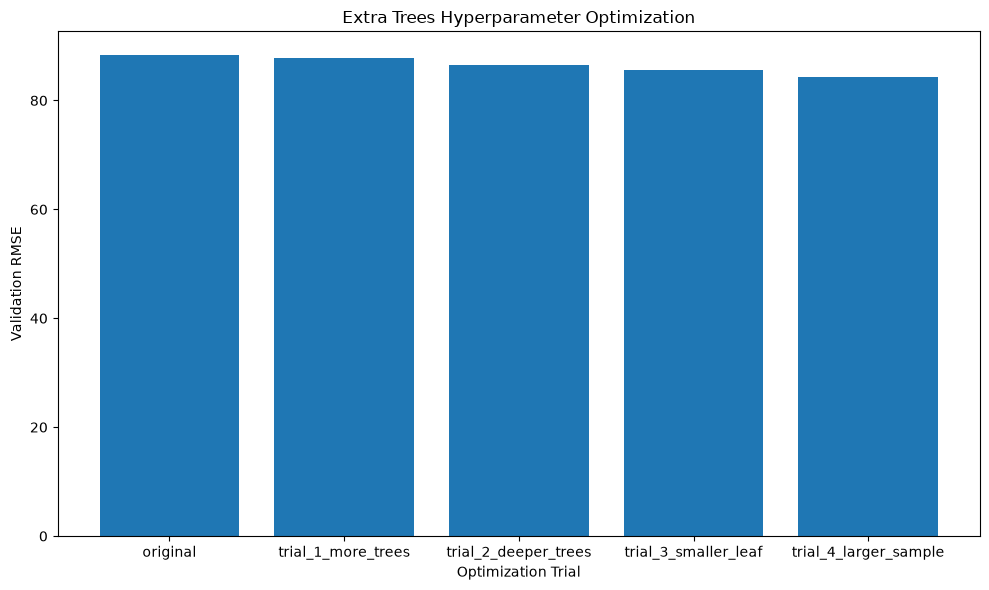

In [38]:
plt.figure(figsize=(10, 6))

plt.bar(
    extra_trees_comparison_df["trial"],
    extra_trees_comparison_df["rmse"],
)

plt.xlabel("Optimization Trial")
plt.ylabel("Validation RMSE")
plt.title("Extra Trees Hyperparameter Optimization")

plt.tight_layout()
plt.show()


Four optimization trials were evaluated against the original Extra Trees model.

The experiments showed that progressively increasing the model complexity improved predictive performance. The largest improvement was obtained by increasing the bootstrap sample fraction from 10% to 20%.

Although the optimized model required approximately twice the training time, it achieved the lowest validation RMSE and MAE. Since predictive accuracy is the primary objective of this project, the optimized Extra Trees configuration will be selected as the candidate model for subsequent comparison with the optimized XGBoost model.

#### 12.3 XGBoost Optimization

The advanced model comparison identified XGBoost as one of the strongest predictive models.

The original XGBoost model achieved the following performance on the development validation split:

```python
XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=20,
    subsample=0.50,
    colsample_bytree=0.80,
    reg_alpha=0.10,
    reg_lambda=1.00,
    tree_method="hist",
    max_bin=256,
    random_state=42,
    n_jobs=4,
)
```

Original performance:

- RMSE: 90.2238
- MAE: 42.2748

The following trials modify selected hyperparameters to investigate whether further improvements can be achieved while maintaining good generalization performance.

##### 12.3.1 XGBoost Trial 1 – Increase the Number of Trees

The first trial increases the number of boosting iterations from 300 to 500 while keeping the remaining parameters unchanged.

A larger number of boosting rounds may improve predictive performance by allowing the model to learn more detailed relationships. However, it also increases training time.

In [39]:
xgboost_trial_1_parameters = {
    "n_estimators": 500,
}

In [40]:
xgboost_trial_1 = create_xgboost_pipeline(
    feature_columns=RAW_FEATURES,
    model_params=xgboost_trial_1_parameters,
)

xgboost_trial_1

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

In [41]:
(
    xgboost_trial_1,
    xgboost_trial_1_predictions,
    xgboost_trial_1_result,
) = evaluate_optimization_trial(
    model=xgboost_trial_1,
    model_name="XGBoost",
    trial_name="trial_1_more_trees",
    parameters=xgboost_trial_1_parameters,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

Model: XGBoost
Trial: trial_1_more_trees
RMSE: 88.6237
MAE: 40.2255
Training time: 212.01 seconds
Prediction time: 5.39 seconds


##### 12.3.2 XGBoost Trial 2 – Reduce the Learning Rate

The second trial reduces the learning rate from 0.05 to 0.03 while increasing the number of boosting rounds.

A lower learning rate allows the model to learn more gradually, which can improve generalization and reduce overfitting.

In [42]:
xgboost_trial_2_parameters = {
    "learning_rate": 0.03,
    "n_estimators": 500,
}

In [43]:
xgboost_trial_2 = create_xgboost_pipeline(
    feature_columns=RAW_FEATURES,
    model_params=xgboost_trial_2_parameters,
)

xgboost_trial_2

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

In [44]:
(
    xgboost_trial_2,
    xgboost_trial_2_predictions,
    xgboost_trial_2_result,
) = evaluate_optimization_trial(
    model=xgboost_trial_2,
    model_name="XGBoost",
    trial_name="trial_2_lower_learning_rate",
    parameters=xgboost_trial_2_parameters,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

Model: XGBoost
Trial: trial_2_lower_learning_rate
RMSE: 90.1227
MAE: 41.7122
Training time: 266.11 seconds
Prediction time: 6.81 seconds


##### 12.3.3 XGBoost Trial 3 – Reduce Maximum Tree Depth

The third trial reduces the maximum tree depth from 8 to 6.

Shallower trees generally produce a simpler model that is less likely to overfit while still capturing the most important relationships within the data.

In [45]:
xgboost_trial_3_parameters = {
    "max_depth": 6,
}

In [46]:
xgboost_trial_3 = create_xgboost_pipeline(
    feature_columns=RAW_FEATURES,
    model_params=xgboost_trial_3_parameters,
)

xgboost_trial_3

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

In [47]:
(
    xgboost_trial_3,
    xgboost_trial_3_predictions,
    xgboost_trial_3_result,
) = evaluate_optimization_trial(
    model=xgboost_trial_3,
    model_name="XGBoost",
    trial_name="trial_3_shallower_trees",
    parameters=xgboost_trial_3_parameters,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

Model: XGBoost
Trial: trial_3_shallower_trees
RMSE: 95.7216
MAE: 51.3939
Training time: 101.73 seconds
Prediction time: 3.25 seconds


##### 12.3.4 XGBoost Trial 4 – Increase Regularization

The fourth trial increases the regularization strength by modifying the minimum child weight and L2 regularization parameters.

Stronger regularization may reduce overfitting and improve the model's ability to generalize to unseen wells.

In [48]:
xgboost_trial_4_parameters = {
    "min_child_weight": 30,
    "reg_lambda": 2.0,
}

In [49]:
xgboost_trial_4 = create_xgboost_pipeline(
    feature_columns=RAW_FEATURES,
    model_params=xgboost_trial_4_parameters,
)

xgboost_trial_4

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

In [50]:
(
    xgboost_trial_4,
    xgboost_trial_4_predictions,
    xgboost_trial_4_result,
) = evaluate_optimization_trial(
    model=xgboost_trial_4,
    model_name="XGBoost",
    trial_name="trial_4_stronger_regularization",
    parameters=xgboost_trial_4_parameters,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
)

Model: XGBoost
Trial: trial_4_stronger_regularization
RMSE: 91.0723
MAE: 42.4816
Training time: 104.00 seconds
Prediction time: 2.74 seconds


##### 12.3.5 Compare XGBoost Trials

In [59]:
xgboost_comparison_df = pd.DataFrame(
    [
        {
            "trial": "Original",
            "rmse": 90.2238,
            "mae": 42.2748,
            "training_seconds": xgboost_metrics["training_seconds"],
            "prediction_seconds": xgboost_metrics["prediction_seconds"],
        },
        {
            "trial": "Trial 1",
            **xgboost_trial_1_result,
        },
        {
            "trial": "Trial 2",
            **xgboost_trial_2_result,
        },
        {
            "trial": "Trial 3",
            **xgboost_trial_3_result,
        },
        {
            "trial": "Trial 4",
            **xgboost_trial_4_result,
        },
    ]
)

In [61]:
xgboost_comparison_df = (
    xgboost_comparison_df
    .sort_values("rmse")
    .reset_index(drop=True)
)

xgboost_comparison_df[
    [
        "trial",
        "rmse",
        "mae",
        "training_seconds",
        "prediction_seconds",
    ]
].round(4)

,trial,rmse,mae,training_seconds,prediction_seconds
0,trial_1_more_trees,88.6237,40.2255,212.0143,5.3949
1,trial_2_lower_learning_rate,90.1227,41.7122,266.1065,6.8148
2,Original,90.2238,42.2748,103.6297,2.6829
3,trial_4_stronger_regularization,91.0723,42.4816,104.0029,2.7400
4,trial_3_shallower_trees,95.7216,51.3939,101.7321,3.2487


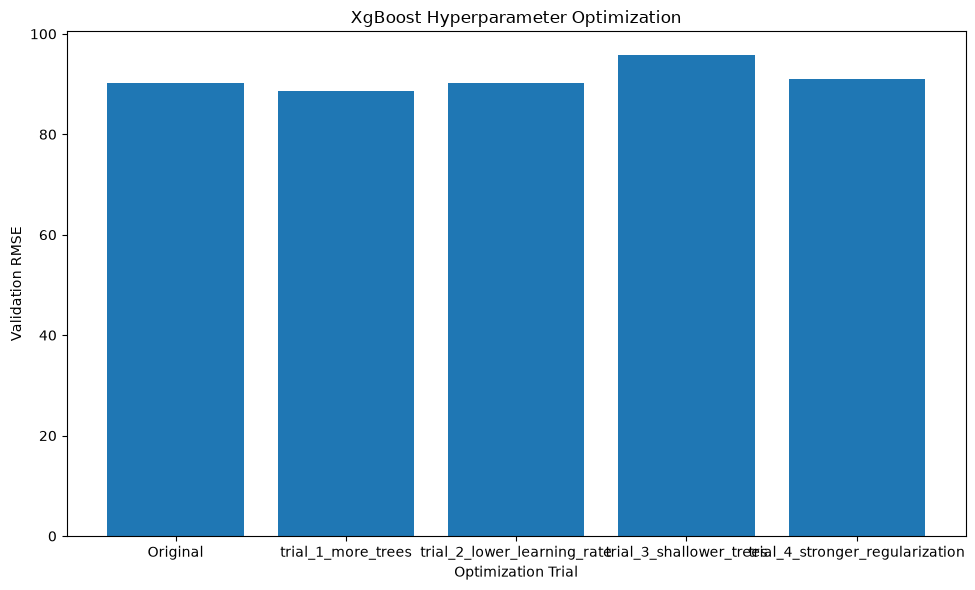

In [60]:
plt.figure(figsize=(10, 6))

plt.bar(
    xgboost_comparison_df["trial"],
    xgboost_comparison_df["rmse"],
)

plt.xlabel("Optimization Trial")
plt.ylabel("Validation RMSE")
plt.title("XgBoost Hyperparameter Optimization")

plt.tight_layout()
plt.show()

In [62]:
best_xgboost_result = (
    xgboost_comparison_df
    .sort_values("rmse")
    .iloc[0]
)

best_xgboost_result

trial                    trial_1_more_trees
rmse                                88.6237
mae                                 40.2255
training_seconds                   212.0143
prediction_seconds                   5.3949
model                               XGBoost
parameters            {'n_estimators': 500}
Name: 0, dtype: object

In [63]:
print(f"Best XGBoost trial: {best_xgboost_result['trial']}")
print(f"RMSE: {best_xgboost_result['rmse']:.4f}")
print(f"MAE: {best_xgboost_result['mae']:.4f}")

Best XGBoost trial: trial_1_more_trees
RMSE: 88.6237
MAE: 40.2255



Four optimization trials were evaluated using the same group-aware development split.

The experiments explored the effect of increasing the number of boosting rounds, reducing the learning rate, simplifying the tree structure, and strengthening regularization.

The best-performing configuration will be compared against the optimized Extra Trees model in the following section to determine the strongest overall model for the remainder of the project.

### 13. Feature Importance Analysis

This section investigates which input features contribute most strongly to the predictions produced by the best optimized model.


#### 13.1 Select the Best Optimized Model

In [64]:
optimization_summary_df = pd.DataFrame(
    [
        {
            "model": "ExtraTrees",
            "trial": "trial_4_larger_sample",
            "pipeline": extra_trees_trial_4,
            "rmse": extra_trees_trial_4_result["rmse"],
            "mae": extra_trees_trial_4_result["mae"],
        },
        {
            "model": "XGBoost",
            "trial": best_xgboost_result["trial"],
            "pipeline": {
                "trial_1_more_trees": xgboost_trial_1,
                "trial_2_lower_learning_rate": xgboost_trial_2,
                "trial_3_shallower_trees": xgboost_trial_3,
                "trial_4_stronger_regularization": xgboost_trial_4,
            }[best_xgboost_result["trial"]],
            "rmse": best_xgboost_result["rmse"],
            "mae": best_xgboost_result["mae"],
        },
    ]
)

optimization_summary_df = (
    optimization_summary_df
    .sort_values("rmse")
    .reset_index(drop=True)
)

optimization_summary_df

,model,trial,pipeline,rmse,mae
0,ExtraTrees,trial_4_larger_sample,"(ColumnTransformer(transformers=[('numeric',\n...",84.2854,37.3521
1,XGBoost,trial_1_more_trees,"(ColumnTransformer(transformers=[('numeric',\n...",88.6237,40.2255


In [65]:
best_model = optimization_summary_df.iloc[0]

best_model_name = best_model["model"]
best_trial_name = best_model["trial"]
best_optimized_pipeline = best_model["pipeline"]

print(f"Best Model : {best_model_name}")
print(f"Best Trial : {best_trial_name}")
print(f"RMSE       : {best_model['rmse']:.4f}")
print(f"MAE        : {best_model['mae']:.4f}")

Best Model : ExtraTrees
Best Trial : trial_4_larger_sample
RMSE       : 84.2854
MAE        : 37.3521


#### 13.2 Extract the Trained Model

In [66]:
best_tree_model = (
    best_optimized_pipeline
    .named_steps["model"]
)

best_tree_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",25
,"bootstrap bootstrap: bool, default=FalseWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls 3 sources of randomness:- the bootstrapping of the samples used when building trees (if ``bootstrap=True``)- the sampling of the features to consider when looking for the best split at each node (if ``max_features < n_features``)- the draw of the splits for each of the `max_features`See :term:`Glossary <random_state>` for details.",42
,"max_samples max_samples: int or float, default=NoneIf bootstrap is True, the number of samples to draw from Xto train each base estimator.- If None (default), then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples... versionadded:: 0.22.. versionchanged:: 1.9 Float `max_samples` is relative to `sample_weight.sum()` instead of `X.shape[0]` for weighted samples.",0.2
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` f

#### 13.3 Confirm the Feature Order

In [67]:
feature_names = list(RAW_FEATURES)

print(f"Number of features: {len(feature_names)}")
print(f"Model importance values: {len(best_tree_model.feature_importances_)}")

Number of features: 12
Model importance values: 12


#### 13.4 Create Built-in Feature Importance Table

In [68]:
built_in_importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": best_tree_model.feature_importances_,
    }
)

built_in_importance_df = (
    built_in_importance_df
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

built_in_importance_df

,feature,importance
0,Z,0.2101
1,EGFDU,0.1271
2,BUDA,0.1263
3,ASTNL,0.1210
4,EGFDL,0.1150
5,ASTNU,0.1142
6,ANCC,0.1142
7,TVT_input,0.0251
8,X,0.0183
9,Y,0.0170


#### 13.5 Display the Top Features

In [69]:
top_built_in_features = built_in_importance_df.head(15)

top_built_in_features

,feature,importance
0,Z,0.2101
1,EGFDU,0.1271
2,BUDA,0.1263
3,ASTNL,0.1210
4,EGFDL,0.1150
5,ASTNU,0.1142
6,ANCC,0.1142
7,TVT_input,0.0251
8,X,0.0183
9,Y,0.0170


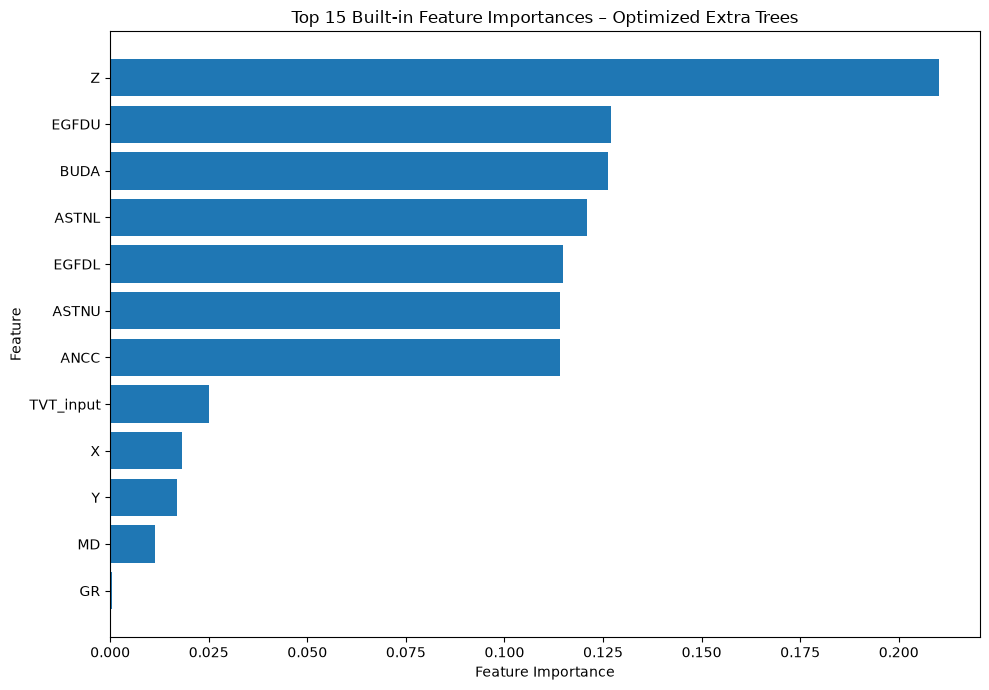

In [70]:
plot_df = (
    top_built_in_features
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"],
    plot_df["importance"],
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top 15 Built-in Feature Importances – Optimized Extra Trees"
)

plt.tight_layout()
plt.show()

The built-in feature importance shows which variables were used most frequently and effectively when creating decision-tree splits.

Higher importance indicates that the feature contributed more strongly to reducing prediction error across the ensemble.

However, built-in tree importance can favour continuous features or correlated variables. Therefore, permutation importance is also calculated.

#### 13.6 Permutation Importance

##### 13.6.1 Create a Validation Sample

In [71]:
PERMUTATION_SAMPLE_SIZE = min(
    100_000,
    len(X_validation),
)

permutation_sample_indices = (
    X_validation
    .sample(
        n=PERMUTATION_SAMPLE_SIZE,
        random_state=42,
    )
    .index
)

X_permutation = X_validation.loc[
    permutation_sample_indices
]

y_permutation = y_validation.loc[
    permutation_sample_indices
]

print(
    "Permutation sample shape:",
    X_permutation.shape,
)

Permutation sample shape: (100000, 12)


##### 13.6.2 Calculate Permutation Importance

In [72]:
permutation_result = permutation_importance(
    estimator=best_optimized_pipeline,
    X=X_permutation,
    y=y_permutation,
    scoring="neg_root_mean_squared_error",
    n_repeats=3,
    random_state=42,
    n_jobs=4,
)

##### 13.6.3 Create the Permutation Importance Table

In [74]:
permutation_importance_df = pd.DataFrame(
    {
        "feature": RAW_FEATURES,
        "importance_mean": permutation_result.importances_mean,
        "importance_std": permutation_result.importances_std,
    }
)

permutation_importance_df = (
    permutation_importance_df
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

permutation_importance_df

,feature,importance_mean,importance_std
0,Z,332.0731,0.5027
1,ASTNU,87.8902,0.2661
2,TVT_input,69.7860,0.4986
3,X,48.2878,0.1863
4,BUDA,45.8367,0.2091
5,ASTNL,44.3822,0.1039
6,Y,36.5921,0.1668
7,EGFDU,34.3064,0.1025
8,ANCC,32.7910,0.1407
9,MD,32.1833,0.2079


##### 13.6.4 Visualize Permutation Importance

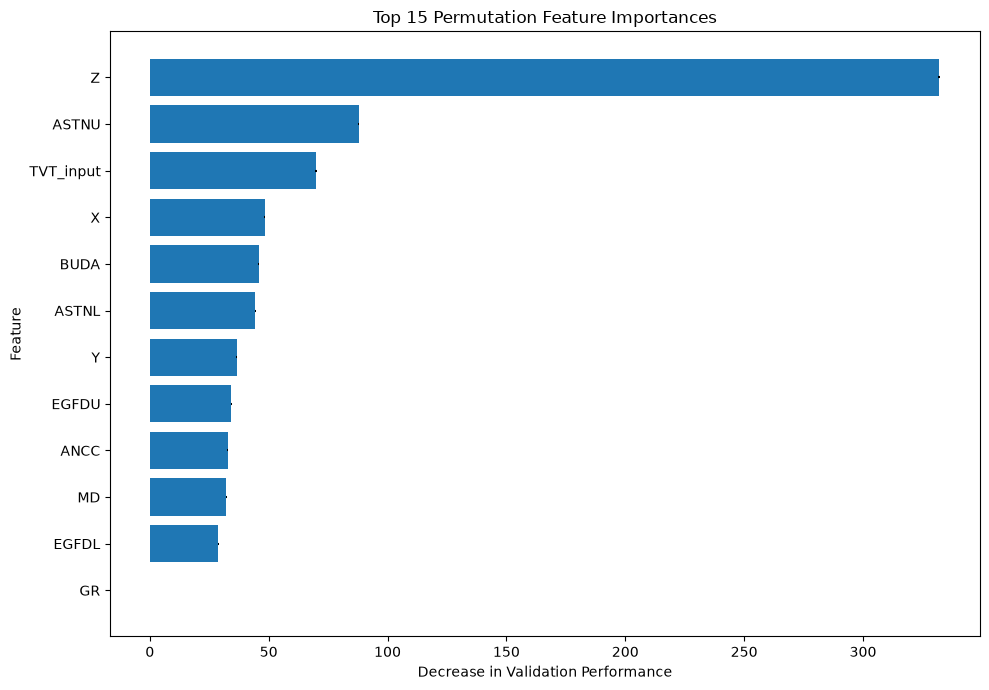

In [75]:
top_permutation_features = (
    permutation_importance_df
    .head(15)
    .sort_values("importance_mean")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_permutation_features["feature"],
    top_permutation_features["importance_mean"],
    xerr=top_permutation_features["importance_std"],
)

plt.xlabel("Decrease in Validation Performance")
plt.ylabel("Feature")
plt.title(
    "Top 15 Permutation Feature Importances"
)

plt.tight_layout()
plt.show()

#### 13.7 Compare the Two Importance Methods

In [76]:
feature_importance_comparison_df = (
    built_in_importance_df
    .rename(
        columns={
            "importance": "built_in_importance",
        }
    )
    .merge(
        permutation_importance_df,
        on="feature",
        how="left",
    )
)

feature_importance_comparison_df[
    [
        "feature",
        "built_in_importance",
        "importance_mean",
        "importance_std",
    ]
].head(20)

,feature,built_in_importance,importance_mean,importance_std
0,Z,0.2101,332.0731,0.5027
1,EGFDU,0.1271,34.3064,0.1025
2,BUDA,0.1263,45.8367,0.2091
3,ASTNL,0.1210,44.3822,0.1039
4,EGFDL,0.1150,28.8739,0.0878
5,ASTNU,0.1142,87.8902,0.2661
6,ANCC,0.1142,32.7910,0.1407
7,TVT_input,0.0251,69.7860,0.4986
8,X,0.0183,48.2878,0.1863
9,Y,0.0170,36.5921,0.1668


In [77]:
feature_importance_comparison_df[
    "built_in_rank"
] = (
    feature_importance_comparison_df[
        "built_in_importance"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

feature_importance_comparison_df[
    "permutation_rank"
] = (
    feature_importance_comparison_df[
        "importance_mean"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

feature_importance_comparison_df = (
    feature_importance_comparison_df
    .sort_values("permutation_rank")
    .reset_index(drop=True)
)

feature_importance_comparison_df[
    [
        "feature",
        "built_in_rank",
        "permutation_rank",
        "built_in_importance",
        "importance_mean",
    ]
].head(15)

,feature,built_in_rank,permutation_rank,built_in_importance,importance_mean
0,Z,1,1,0.2101,332.0731
1,ASTNU,6,2,0.1142,87.8902
2,TVT_input,8,3,0.0251,69.7860
3,X,9,4,0.0183,48.2878
4,BUDA,3,5,0.1263,45.8367
5,ASTNL,4,6,0.1210,44.3822
6,Y,10,7,0.0170,36.5921
7,EGFDU,2,8,0.1271,34.3064
8,ANCC,7,9,0.1142,32.7910
9,MD,11,10,0.0114,32.1833


#### 13.8 Compare the Two Importance Methods

In [78]:
feature_importance_comparison_df = (
    built_in_importance_df
    .rename(
        columns={
            "importance": "built_in_importance",
        }
    )
    .merge(
        permutation_importance_df,
        on="feature",
        how="left",
    )
)

feature_importance_comparison_df[
    [
        "feature",
        "built_in_importance",
        "importance_mean",
        "importance_std",
    ]
].head(20)

,feature,built_in_importance,importance_mean,importance_std
0,Z,0.2101,332.0731,0.5027
1,EGFDU,0.1271,34.3064,0.1025
2,BUDA,0.1263,45.8367,0.2091
3,ASTNL,0.1210,44.3822,0.1039
4,EGFDL,0.1150,28.8739,0.0878
5,ASTNU,0.1142,87.8902,0.2661
6,ANCC,0.1142,32.7910,0.1407
7,TVT_input,0.0251,69.7860,0.4986
8,X,0.0183,48.2878,0.1863
9,Y,0.0170,36.5921,0.1668


In [79]:
feature_importance_comparison_df[
    "built_in_rank"
] = (
    feature_importance_comparison_df[
        "built_in_importance"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

feature_importance_comparison_df[
    "permutation_rank"
] = (
    feature_importance_comparison_df[
        "importance_mean"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

feature_importance_comparison_df = (
    feature_importance_comparison_df
    .sort_values("permutation_rank")
    .reset_index(drop=True)
)

feature_importance_comparison_df[
    [
        "feature",
        "built_in_rank",
        "permutation_rank",
        "built_in_importance",
        "importance_mean",
    ]
].head(15)

,feature,built_in_rank,permutation_rank,built_in_importance,importance_mean
0,Z,1,1,0.2101,332.0731
1,ASTNU,6,2,0.1142,87.8902
2,TVT_input,8,3,0.0251,69.7860
3,X,9,4,0.0183,48.2878
4,BUDA,3,5,0.1263,45.8367
5,ASTNL,4,6,0.1210,44.3822
6,Y,10,7,0.0170,36.5921
7,EGFDU,2,8,0.1271,34.3064
8,ANCC,7,9,0.1142,32.7910
9,MD,11,10,0.0114,32.1833


#### 13.9 Save Feature Importance Results

In [80]:
built_in_importance_path = (
    NOTEBOOK_06_RESULTS_DIR
    / "built_in_feature_importance.csv"
)

built_in_importance_df.to_csv(
    built_in_importance_path,
    index=False,
)

In [81]:
permutation_importance_path = (
    NOTEBOOK_06_RESULTS_DIR
    / "permutation_feature_importance.csv"
)

permutation_importance_df.to_csv(
    permutation_importance_path,
    index=False,
)

In [82]:
feature_importance_comparison_path = (
    NOTEBOOK_06_RESULTS_DIR
    / "feature_importance_comparison.csv"
)

feature_importance_comparison_df.to_csv(
    feature_importance_comparison_path,
    index=False,
)

print("Feature importance results saved successfully.")

Feature importance results saved successfully.


### 14. Error Analysis

This section performs a detailed analysis of the prediction errors produced by the selected optimized model.

The analysis investigates:

- Residual distribution
- Overall error bias
- Well-level RMSE and MAE
- Best and worst validation wells
- Error changes along measured depth
- Actual and predicted TVT profiles for selected wells

The purpose is to understand the limitations of the model before saving it and preparing the final Kaggle submission workflow.

#### 14.1 Generate Predictions from the Selected Model

In [83]:
best_validation_predictions = (
    best_optimized_pipeline.predict(
        X_validation
    )
)

In [84]:
best_predictions_df = pd.DataFrame(
    {
        "well_id": groups_validation.to_numpy(),
        "actual_tvt": y_validation.to_numpy(),
        "predicted_tvt": best_validation_predictions,
    },
    index=X_validation.index,
)

In [85]:
best_predictions_df["MD"] = (
    X_validation["MD"].to_numpy()
)

In [86]:
best_predictions_df["residual"] = (
    best_predictions_df["actual_tvt"]
    - best_predictions_df["predicted_tvt"]
)

best_predictions_df["absolute_error"] = (
    best_predictions_df["residual"].abs()
)

In [87]:
best_predictions_df.head()

,well_id,actual_tvt,predicted_tvt,MD,residual,absolute_error
12837,00e12e8b,"10,606.1800","10,577.2081","10,456.0000",28.9719,28.9719
12838,00e12e8b,"10,607.5300","10,579.1766","10,457.0000",28.3534,28.3534
12839,00e12e8b,"10,608.8800","10,579.8686","10,458.0000",29.0114,29.0114
12840,00e12e8b,"10,610.2200","10,579.7999","10,459.0000",30.4201,30.4201
12841,00e12e8b,"10,611.5700","10,580.4966","10,460.0000",31.0734,31.0734


#### 14.2 Residual Summary Statistics

In [88]:
residual_summary = (
    best_predictions_df["residual"]
    .describe()
)

residual_summary

count   1,044,037.0000
mean            8.2992
std            83.8758
min          -498.0565
25%            -9.6708
50%             0.1071
75%            12.4147
max           660.1367
Name: residual, dtype: float64

In [89]:
mean_residual = (
    best_predictions_df["residual"].mean()
)

median_residual = (
    best_predictions_df["residual"].median()
)

print(f"Mean residual: {mean_residual:.4f}")
print(f"Median residual: {median_residual:.4f}")

Mean residual: 8.2992
Median residual: 0.1071


#### 14.3 Residual Distribution

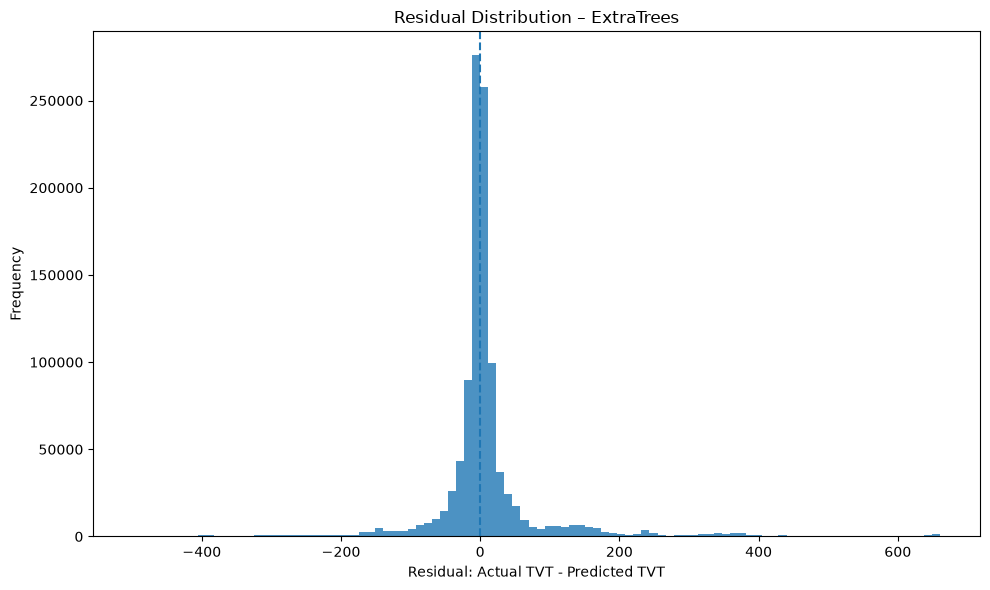

In [90]:
plt.figure(figsize=(10, 6))

plt.hist(
    best_predictions_df["residual"],
    bins=100,
    alpha=0.8,
)

plt.axvline(
    0,
    linestyle="--",
)

plt.xlabel("Residual: Actual TVT - Predicted TVT")
plt.ylabel("Frequency")
plt.title(
    f"Residual Distribution – {best_model_name}"
)

plt.tight_layout()
plt.show()

#### 14.4 Actual vs Predicted TVT

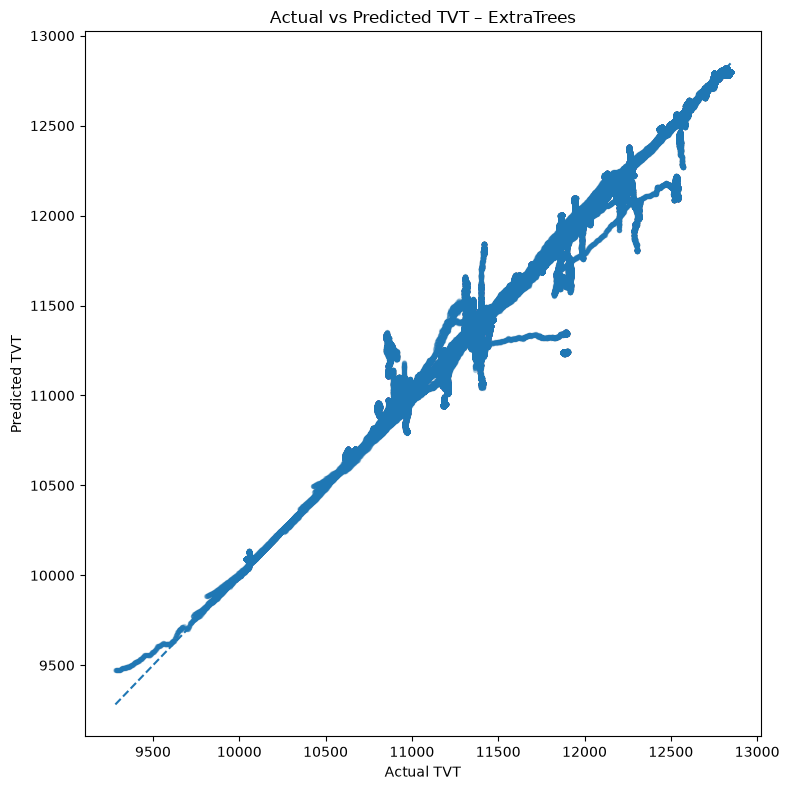

In [91]:
plt.figure(figsize=(8, 8))

plt.scatter(
    best_predictions_df["actual_tvt"],
    best_predictions_df["predicted_tvt"],
    alpha=0.15,
    s=8,
)

minimum_value = min(
    best_predictions_df["actual_tvt"].min(),
    best_predictions_df["predicted_tvt"].min(),
)

maximum_value = max(
    best_predictions_df["actual_tvt"].max(),
    best_predictions_df["predicted_tvt"].max(),
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
)

plt.xlabel("Actual TVT")
plt.ylabel("Predicted TVT")
plt.title(
    f"Actual vs Predicted TVT – {best_model_name}"
)

plt.tight_layout()
plt.show()

#### 14.5 Calculate Well-Level Metrics

In [92]:
best_well_metrics_df = (
    calculate_well_level_metrics(
        predictions=best_predictions_df,
        model_name=best_model_name,
    )
)

In [93]:
best_well_metrics_df = (
    best_well_metrics_df
    .sort_values("rmse")
    .reset_index(drop=True)
)

best_well_metrics_df.head()

,well_id,model,rmse,mae,n_rows
0,9bd2bba3,ExtraTrees,2.6764,2.0969,9092
1,e7c36e81,ExtraTrees,3.5502,2.8467,5655
2,18d24f7b,ExtraTrees,3.7837,3.1764,6260
3,43c7f85a,ExtraTrees,4.1442,3.0438,7484
4,4ddde4c1,ExtraTrees,4.3394,3.4988,6417


#### 14.6 Well-Level Error Distribution

In [94]:
best_well_metrics_df[
    ["rmse", "mae"]
].describe()

,rmse,mae
count,155.0000,155.0000
mean,43.5307,37.0380
std,74.4523,69.7532
min,2.6764,2.0969
25%,9.3066,7.7689
50%,17.4479,12.5055
75%,39.0857,30.8739
max,603.0853,593.7352


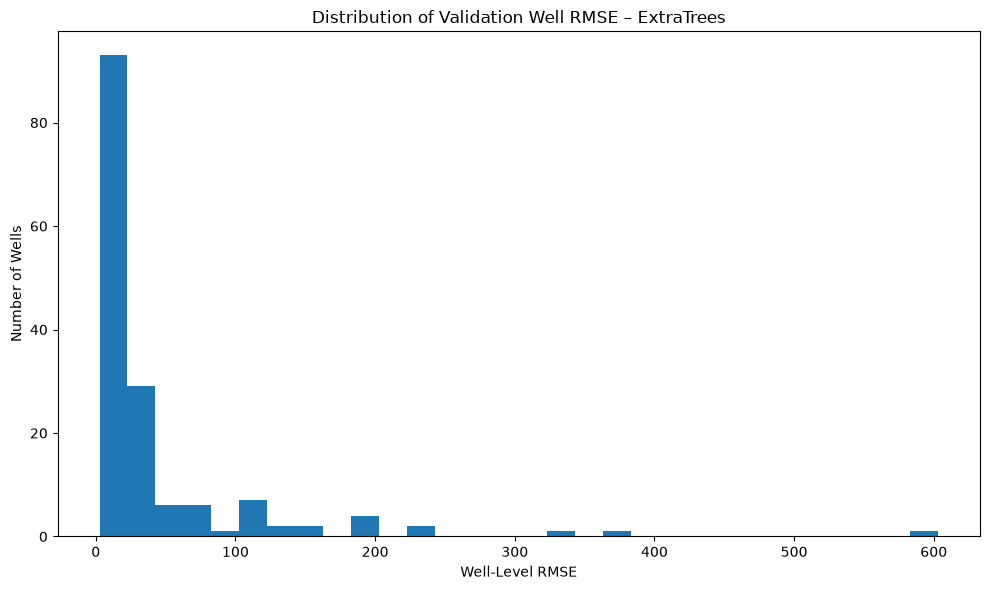

In [95]:
plt.figure(figsize=(10, 6))

plt.hist(
    best_well_metrics_df["rmse"],
    bins=30,
)

plt.xlabel("Well-Level RMSE")
plt.ylabel("Number of Wells")
plt.title(
    f"Distribution of Validation Well RMSE – {best_model_name}"
)

plt.tight_layout()
plt.show()

#### 14.7 Identify Best, Median and Worst Wells

In [96]:
best_well = (
    best_well_metrics_df
    .iloc[0]["well_id"]
)

median_position = (
    len(best_well_metrics_df) // 2
)

median_well = (
    best_well_metrics_df
    .iloc[median_position]["well_id"]
)

worst_well = (
    best_well_metrics_df
    .iloc[-1]["well_id"]
)

print(f"Best well: {best_well}")
print(f"Median well: {median_well}")
print(f"Worst well: {worst_well}")

Best well: 9bd2bba3
Median well: 807f0298
Worst well: 3a7dd95d


In [97]:
selected_well_metrics = (
    best_well_metrics_df[
        best_well_metrics_df["well_id"].isin(
            [
                best_well,
                median_well,
                worst_well,
            ]
        )
    ]
)

selected_well_metrics

,well_id,model,rmse,mae,n_rows
0,9bd2bba3,ExtraTrees,2.6764,2.0969,9092
77,807f0298,ExtraTrees,17.4479,12.5926,5499
154,3a7dd95d,ExtraTrees,603.0853,593.7352,4320


#### 14.8 Plot Actual and Predicted TVT for Selected Wells

In [98]:
def plot_well_prediction(
    predictions_df,
    well_id,
    title_label,
):
    well_df = (
        predictions_df[
            predictions_df["well_id"] == well_id
        ]
        .sort_values("MD")
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        well_df["MD"],
        well_df["actual_tvt"],
        label="Actual TVT",
    )

    plt.plot(
        well_df["MD"],
        well_df["predicted_tvt"],
        label="Predicted TVT",
    )

    plt.xlabel("Measured Depth")
    plt.ylabel("TVT")
    plt.title(
        f"{title_label} Validation Well – {well_id}"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

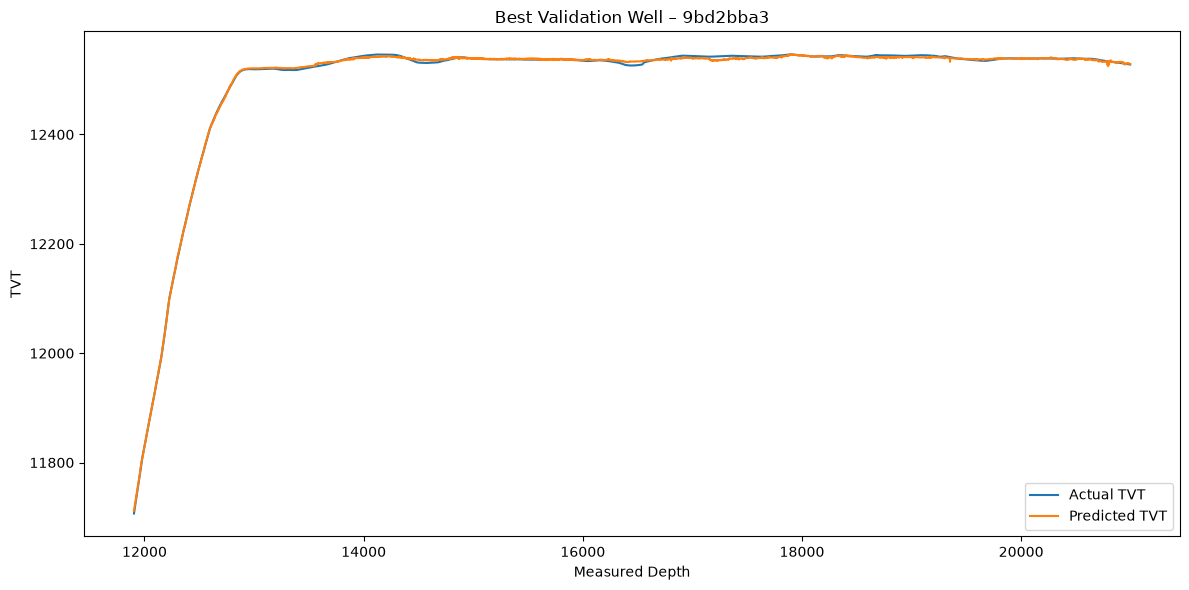

In [99]:
plot_well_prediction(
    predictions_df=best_predictions_df,
    well_id=best_well,
    title_label="Best",
)

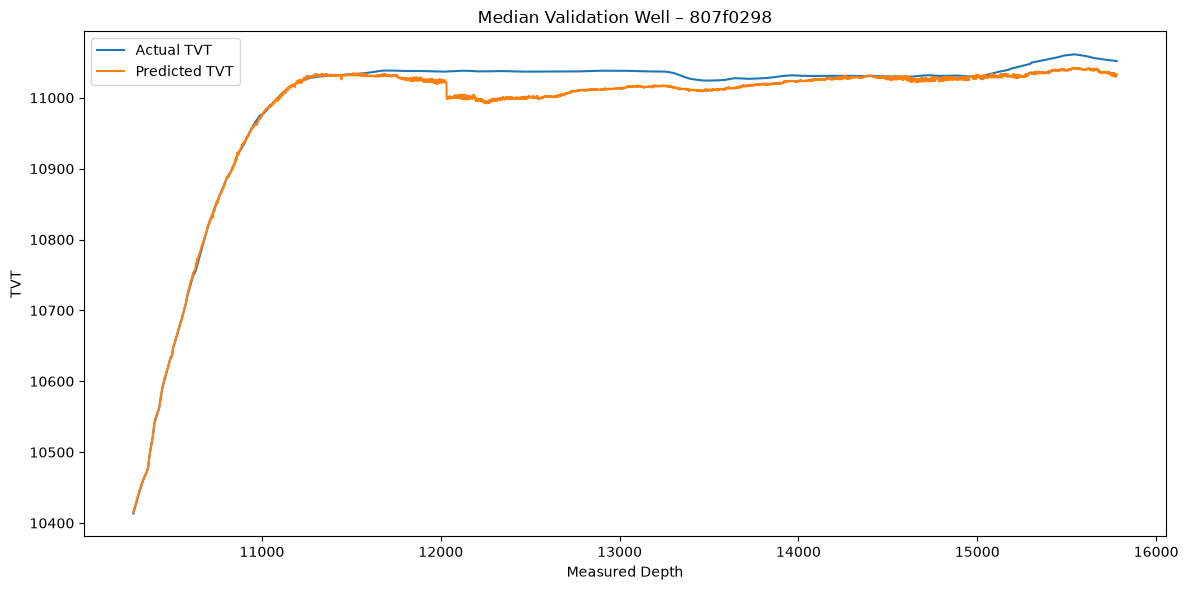

In [100]:
plot_well_prediction(
    predictions_df=best_predictions_df,
    well_id=median_well,
    title_label="Median",
)

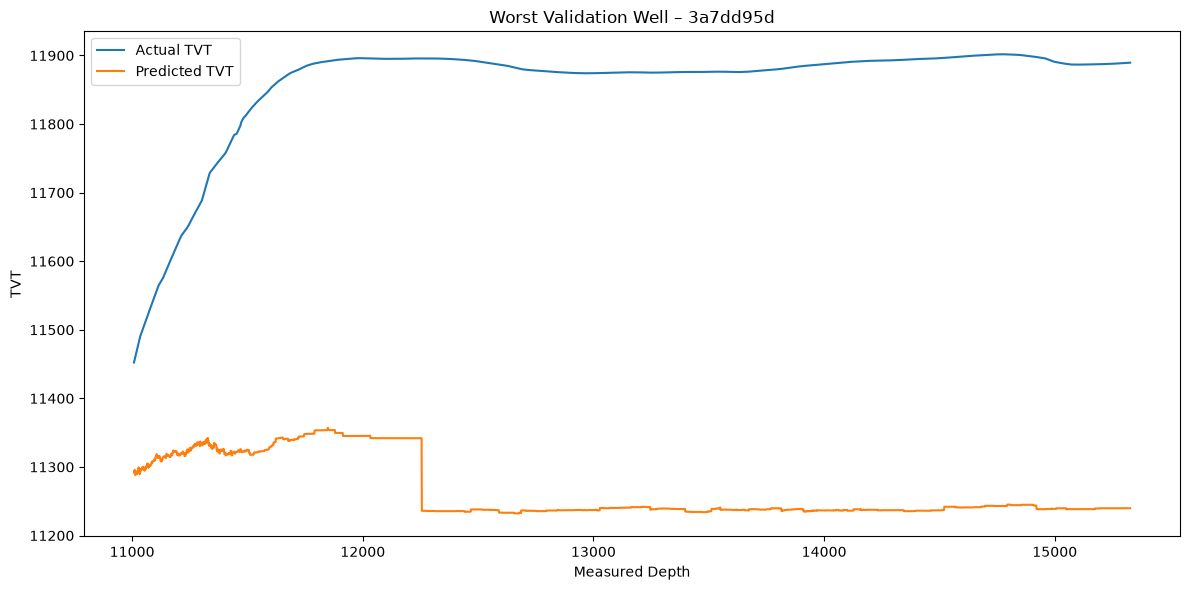

In [101]:
plot_well_prediction(
    predictions_df=best_predictions_df,
    well_id=worst_well,
    title_label="Worst",
)

#### 14.9 Error Along Measured Depth

In [102]:
best_predictions_df["MD_relative"] = (
    best_predictions_df["MD"]
    - best_predictions_df.groupby(
        "well_id"
    )["MD"].transform("min")
)

In [103]:
best_predictions_df["well_progress"] = (
    best_predictions_df["MD_relative"]
    / best_predictions_df.groupby(
        "well_id"
    )["MD_relative"].transform("max")
)

In [104]:
best_predictions_df["well_progress"] = (
    best_predictions_df["well_progress"]
    .fillna(0)
)

In [105]:
best_predictions_df["progress_bin"] = pd.cut(
    best_predictions_df["well_progress"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True,
)

In [106]:
error_by_progress_df = (
    best_predictions_df
    .groupby(
        "progress_bin",
        observed=False,
    )
    .agg(
        mean_absolute_error=(
            "absolute_error",
            "mean",
        ),
        mean_residual=(
            "residual",
            "mean",
        ),
        row_count=(
            "residual",
            "size",
        ),
    )
    .reset_index()
)

error_by_progress_df

,progress_bin,mean_absolute_error,mean_residual,row_count
0,"(-0.001, 0.1]",10.2423,2.1776,104476
1,"(0.1, 0.2]",21.3581,5.5368,104395
2,"(0.2, 0.3]",32.8350,9.4337,104377
3,"(0.3, 0.4]",38.1384,10.3265,104396
4,"(0.4, 0.5]",41.0031,11.2640,104410
5,"(0.5, 0.6]",42.5889,11.0726,104365
6,"(0.6, 0.7]",43.7696,8.5617,104384
7,"(0.7, 0.8]",44.4684,6.2268,104389
8,"(0.8, 0.9]",47.1810,8.0091,104383
9,"(0.9, 1.0]",51.9507,10.3870,104462


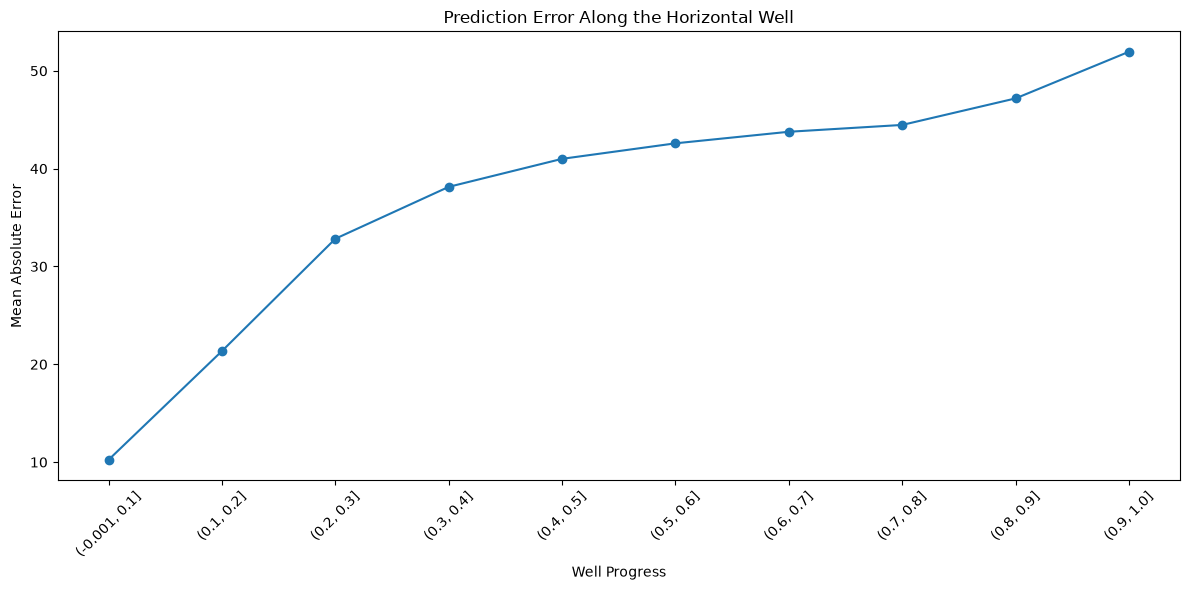

In [107]:
plt.figure(figsize=(12, 6))

plt.plot(
    error_by_progress_df[
        "progress_bin"
    ].astype(str),
    error_by_progress_df[
        "mean_absolute_error"
    ],
    marker="o",
)

plt.xlabel("Well Progress")
plt.ylabel("Mean Absolute Error")
plt.title(
    "Prediction Error Along the Horizontal Well"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 14.10 Inspect the Largest Individual Errors

In [108]:
largest_errors_df = (
    best_predictions_df
    .sort_values(
        "absolute_error",
        ascending=False,
    )
    .head(20)
)

largest_errors_df[
    [
        "well_id",
        "MD",
        "actual_tvt",
        "predicted_tvt",
        "residual",
        "absolute_error",
    ]
]

,well_id,MD,actual_tvt,predicted_tvt,residual,absolute_error
1149849,3a7dd95d,"12,315.0000","11,895.6200","11,235.4833",660.1367,660.1367
1149850,3a7dd95d,"12,316.0000","11,895.6200","11,235.4862",660.1338,660.1338
1149851,3a7dd95d,"12,317.0000","11,895.6100","11,235.4833",660.1267,660.1267
1149853,3a7dd95d,"12,319.0000","11,895.6000","11,235.5367",660.0633,660.0633
1149852,3a7dd95d,"12,318.0000","11,895.6000","11,235.5396",660.0604,660.0604
1149854,3a7dd95d,"12,320.0000","11,895.5900","11,235.5396",660.0504,660.0504
1149855,3a7dd95d,"12,321.0000","11,895.5800","11,235.5367",660.0433,660.0433
1149809,3a7dd95d,"12,275.0000","11,895.7700","11,235.7337",660.0363,660.0363
1149857,3a7dd95d,"12,323.0000","11,895.5700","11,235.5396",660.0304,660.0304
1149856,3a7dd95d,"12,322.0000","11,895.5700","11,235.5396",660.0304,660.0304


#### 14.11 Save Error Analysis Results

In [112]:
predictions_to_save = (
    best_predictions_df
    .drop(columns=["progress_bin"])
)

predictions_to_save.to_parquet(
    predictions_output_path,
    index=False,
)

print("Validation predictions saved successfully.")

Validation predictions saved successfully.


In [113]:
well_metrics_output_path = (
    NOTEBOOK_06_RESULTS_DIR
    / "optimized_model_well_metrics.csv"
)

best_well_metrics_df.to_csv(
    well_metrics_output_path,
    index=False,
)

In [114]:
error_progress_output_path = (
    NOTEBOOK_06_RESULTS_DIR
    / "error_by_well_progress.csv"
)

error_by_progress_df.to_csv(
    error_progress_output_path,
    index=False,
)

print("Error analysis results saved successfully.")

Error analysis results saved successfully.


### 15. Save Optimized Model and Results

This section saves the final optimized model selected using validation RMSE.

The saved artifacts include:

- Best fitted preprocessing and model pipeline
- Final model metadata
- Optimized model comparison results
- Feature importance results
- Error-analysis outputs

Saving the complete pipeline ensures that the same preprocessing steps are applied when generating predictions for unseen Kaggle test data or when deploying the model in an application.

#### 15.1 Confirm the Selected Model

In [115]:
print(f"Selected model: {best_model_name}")
print(f"Selected trial: {best_trial_name}")
print(f"Validation RMSE: {best_model['rmse']:.4f}")
print(f"Validation MAE: {best_model['mae']:.4f}")

best_optimized_pipeline

Selected model: ExtraTrees
Selected trial: trial_4_larger_sample
Validation RMSE: 84.2854
Validation MAE: 37.3521


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['MD','GR','TVT_input',...,'EGFDU','EGFDL','BUDA']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output

#### 15.2 Create the Output Directories

In [116]:
NOTEBOOK_06_MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

NOTEBOOK_06_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Models directory:", NOTEBOOK_06_MODELS_DIR)
print("Results directory:", NOTEBOOK_06_RESULTS_DIR)

Models directory: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\models\notebook_06
Results directory: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_06


#### 15.3 Save the Best Fitted Pipeline

In [117]:
best_model_path = (
    NOTEBOOK_06_MODELS_DIR
    / "best_optimized_pipeline.joblib"
)

joblib.dump(
    best_optimized_pipeline,
    best_model_path,
)

print("Best optimized pipeline saved to:")
print(best_model_path)

Best optimized pipeline saved to:
C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\models\notebook_06\best_optimized_pipeline.joblib


#### 15.4 Verify the Saved Pipeline

In [118]:
loaded_optimized_pipeline = joblib.load(
    best_model_path
)

loaded_predictions = (
    loaded_optimized_pipeline.predict(
        X_validation
    )
)

In [119]:
predictions_match = np.allclose(
    loaded_predictions,
    best_validation_predictions,
)

print(
    "Loaded predictions match original predictions:",
    predictions_match,
)

Loaded predictions match original predictions: True


#### 15.5 Create Model Metadata

In [120]:
best_model_metadata = {
    "model_name": best_model_name,
    "trial_name": best_trial_name,
    "validation_rmse": float(best_model["rmse"]),
    "validation_mae": float(best_model["mae"]),
    "target_column": TARGET_COLUMN,
    "group_column": GROUP_COLUMN,
    "feature_count": len(RAW_FEATURES),
    "feature_columns": list(RAW_FEATURES),
    "training_rows": len(X_train),
    "validation_rows": len(X_validation),
    "training_wells": int(groups_train.nunique()),
    "validation_wells": int(groups_validation.nunique()),
    "random_state": 42,
}

In [121]:
best_model_metadata

{'model_name': 'ExtraTrees',
 'trial_name': 'trial_4_larger_sample',
 'validation_rmse': 84.28539159526252,
 'validation_mae': 37.352140491937476,
 'target_column': 'TVT',
 'group_column': 'well_id',
 'feature_count': 12,
 'feature_columns': ['MD',
  'GR',
  'TVT_input',
  'X',
  'Y',
  'Z',
  'ANCC',
  'ASTNU',
  'ASTNL',
  'EGFDU',
  'EGFDL',
  'BUDA'],
 'training_rows': 4048218,
 'validation_rows': 1044037,
 'training_wells': 618,
 'validation_wells': 155,
 'random_state': 42}

#### 15.6 Save Metadata as JSON

In [123]:
metadata_path = (
    NOTEBOOK_06_RESULTS_DIR
    / "best_optimized_model_metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        best_model_metadata,
        metadata_file,
        indent=4,
    )

print("Model metadata saved to:")
print(metadata_path)

Model metadata saved to:
C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_06\best_optimized_model_metadata.json


#### 15.7 Save Final Optimized Model Comparison

In [124]:
final_optimized_comparison_df = (
    optimization_summary_df[
        [
            "model",
            "trial",
            "rmse",
            "mae",
        ]
    ]
    .copy()
)

In [125]:
final_optimized_comparison_path = (
    NOTEBOOK_06_RESULTS_DIR
    / "final_optimized_model_comparison.csv"
)

final_optimized_comparison_df.to_csv(
    final_optimized_comparison_path,
    index=False,
)

final_optimized_comparison_df

,model,trial,rmse,mae
0,ExtraTrees,trial_4_larger_sample,84.2854,37.3521
1,XGBoost,trial_1_more_trees,88.6237,40.2255


#### 15.8 Save All Hyperparameter Trials

In [126]:
all_optimization_trials_df = pd.DataFrame(
    optimization_results
)

In [127]:
all_optimization_trials_df[
    "parameters"
] = all_optimization_trials_df[
    "parameters"
].apply(json.dumps)

In [128]:
all_trials_path = (
    NOTEBOOK_06_RESULTS_DIR
    / "all_hyperparameter_trials.csv"
)

all_optimization_trials_df.to_csv(
    all_trials_path,
    index=False,
)

print("All optimization trials saved to:")
print(all_trials_path)

All optimization trials saved to:
C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_06\all_hyperparameter_trials.csv


#### 15.9 Save the Feature List Separately

In [129]:
feature_list_path = (
    NOTEBOOK_06_RESULTS_DIR
    / "model_feature_columns.json"
)

with open(
    feature_list_path,
    "w",
    encoding="utf-8",
) as feature_file:
    json.dump(
        list(RAW_FEATURES),
        feature_file,
        indent=4,
    )

print("Feature list saved to:")
print(feature_list_path)

Feature list saved to:
C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\results\notebook_06\model_feature_columns.json


#### 15.10 Verify All Saved Files

In [130]:
saved_artifacts = [
    best_model_path,
    metadata_path,
    final_optimized_comparison_path,
    all_trials_path,
    feature_list_path,
    predictions_output_path,
    well_metrics_output_path,
    error_progress_output_path,
]

for artifact_path in saved_artifacts:
    print(
        f"{artifact_path.name}: "
        f"{artifact_path.exists()}"
    )

best_optimized_pipeline.joblib: True
best_optimized_model_metadata.json: True
final_optimized_model_comparison.csv: True
all_hyperparameter_trials.csv: True
model_feature_columns.json: True
optimized_model_validation_predictions.parquet: True
optimized_model_well_metrics.csv: True
error_by_well_progress.csv: True


#### 15.11 Final Artifact Summary

In [131]:
artifact_summary_df = pd.DataFrame(
    {
        "artifact": [
            path.name
            for path in saved_artifacts
        ],
        "location": [
            str(path)
            for path in saved_artifacts
        ],
        "exists": [
            path.exists()
            for path in saved_artifacts
        ],
    }
)

artifact_summary_df

,artifact,location,exists
0,best_optimized_pipeline.joblib,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,True
1,best_optimized_model_metadata.json,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,True
2,final_optimized_model_comparison.csv,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,True
3,all_hyperparameter_trials.csv,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,True
4,model_feature_columns.json,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,True
5,optimized_model_validation_predictions.parquet,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,True
6,optimized_model_well_metrics.csv,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,True
7,error_by_well_progress.csv,C:\Dev\Rogii Wellbore Geology\rogii-wellbore-g...,True


The selected optimized model was saved as a complete fitted pipeline containing both preprocessing and prediction logic.

The saved pipeline was loaded successfully and reproduced the original validation predictions, confirming that the artifact is valid.

Additional metadata, feature definitions, hyperparameter trials, model comparisons, feature-importance outputs, and error-analysis results were also saved.

These artifacts provide the foundation for the next notebook, where the model will be validated more rigorously and used to generate Kaggle test predictions and a submission file.

### 16. Conclusions

Notebook 06 compared four advanced regression models—HistGradientBoosting, Extra Trees, XGBoost, and LightGBM—using the same group-aware development split.

Extra Trees achieved the strongest initial performance and, together with XGBoost, was selected for hyperparameter optimization. The best configuration was Extra Trees trial_4_larger_sample, which achieved:

Validation RMSE: 84.2854
Validation MAE: 37.3521
Compared with the original Extra Trees model, optimization reduced RMSE by 4.53% and MAE by 11.58%. It also outperformed the best optimized XGBoost trial, whose RMSE and MAE were 88.6237 and 40.2255, respectively.

Feature-importance analysis identified Z as the most influential feature using both built-in and permutation importance. ASTNU and TVT_input also ranked highly under permutation importance, while GR contributed very little.

Error analysis showed substantial variation between wells. The median well RMSE was approximately 17.45, but a small number of difficult wells produced much larger errors, with the worst well reaching an RMSE of approximately 603.09. Prediction error also generally increased toward the end of each well, indicating that later measured-depth intervals remain more challenging.

Overall, the optimized Extra Trees pipeline is the strongest model produced so far on the development split. The fitted pipeline, metadata, optimization results, feature importance outputs, validation predictions, and well-level error results were saved successfully. These artifacts are ready for stronger group-aware cross-validation, possible ensemble development, and final Kaggle prediction and submission generation.